# Maintenance Prédictive — Pipeline Complet## Projet PFE · Cevital ·
Prédiction RUL par LSTM---**Structure du notebook :**| Phase | Contenu ||-------|---------|| **Phase 1** | EDA — Données brutes (failure1.csv) || **Phase 2** | Feature Engineering (Dataset V1 — END_DATE) || **Phase 3** | EDA — Features créées || **Phase 4** | Prétraitement LSTM || **Phase 5** | Optimisation Bayésienne des Hyperparamètres || **Phase 6** | Entraînement LSTM + Évaluation Complète |---## ⚙️ Paramètres globaux

In [1]:
# ── Paramètres globaux ────────────────────────────────────────────
MIN_FAILURES  = 2          # Nombre minimum de pannes pour modéliser un composant
YEAR          = 2023       # Année d'étude
LOOKBACK      = 30         # Taille de la fenêtre temporelle LSTM
MAX_RUL       = 30         # Clip RUL pour le modèle CHAMPION
ALERT_DAYS    = 10         # Seuil d'alerte critique
RANDOM_STATE  = 42

PATH_FAILURE   = 'failure1.csv'
PATH_EQUIPMENT = 'equipment_clean.csv'
PATH_DATASET   = 'Dataset_V1_maintenance_enddate2.csv'

print(f'MIN_FAILURES = {MIN_FAILURES} | YEAR = {YEAR} | LOOKBACK = {LOOKBACK} | MAX_RUL = {MAX_RUL}')

MIN_FAILURES = 2 | YEAR = 2023 | LOOKBACK = 30 | MAX_RUL = 30


---# 📊 Phase 1 — EDA Données Brutes**Objectif :** Diagnostiquer l'état initial des données avant toute modification.> **Entrée :** `failure1.csv` brut (tous niveaux, 2023 + 2024)

## 1.1 — Imports et chargement

In [2]:
# =====================================================================
# EDA PHASE 1 — Données Brutes failure1.csv
# Dataset complet : 2023 + 2024
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Chargement ───────────────────────────────────────────────────────
df = pd.read_csv('failure1.csv', encoding='utf-8-sig',
                 parse_dates=['WOWO_DECLARATION_DATE', 'WOWO_END_DATE'])

df['annee'] = df['WOWO_DECLARATION_DATE'].dt.year
df['mois']  = df['WOWO_DECLARATION_DATE'].dt.month
df['duree'] = (df['WOWO_END_DATE'] - df['WOWO_DECLARATION_DATE']).dt.days

# Filtrage 2023 (dataset d'étude)
df23 = df[df['annee'] == 2023].copy()
df34 = df23[df23['WOWO_EQUIPMENT_LEVEL'].isin([3.0, 4.0])].copy()

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aoû','Sep','Oct','Nov','Déc']

print('=' * 65)
print('  VUE D\'ENSEMBLE GÉNÉRALE — failure1.csv')
print('=' * 65)
print(f'  Total OT (2023+2024)      : {len(df):,}')
print(f'  Total OT 2023             : {len(df23):,}')
print(f'  OT niveaux 3+4 (2023)     : {len(df34):,}')
print(f'  Composants uniques (3+4)  : {df34["WOWO_EQUIPMENT"].nunique()}')
print(f'  Machines mères (3+4)      : {df34["WOWO_SYSTEM_EQUIPMENT"].nunique()}')
print(f'  Période                   : {df["WOWO_DECLARATION_DATE"].min().date()} → {df["WOWO_DECLARATION_DATE"].max().date()}')
print('=' * 65)

  VUE D'ENSEMBLE GÉNÉRALE — failure1.csv
  Total OT (2023+2024)      : 8,065
  Total OT 2023             : 4,757
  OT niveaux 3+4 (2023)     : 1,085
  Composants uniques (3+4)  : 344
  Machines mères (3+4)      : 90
  Période                   : 2023-01-01 → 2024-05-28


## 1.2 — Qualité des données


📊 SECTION 1 — Qualité des données


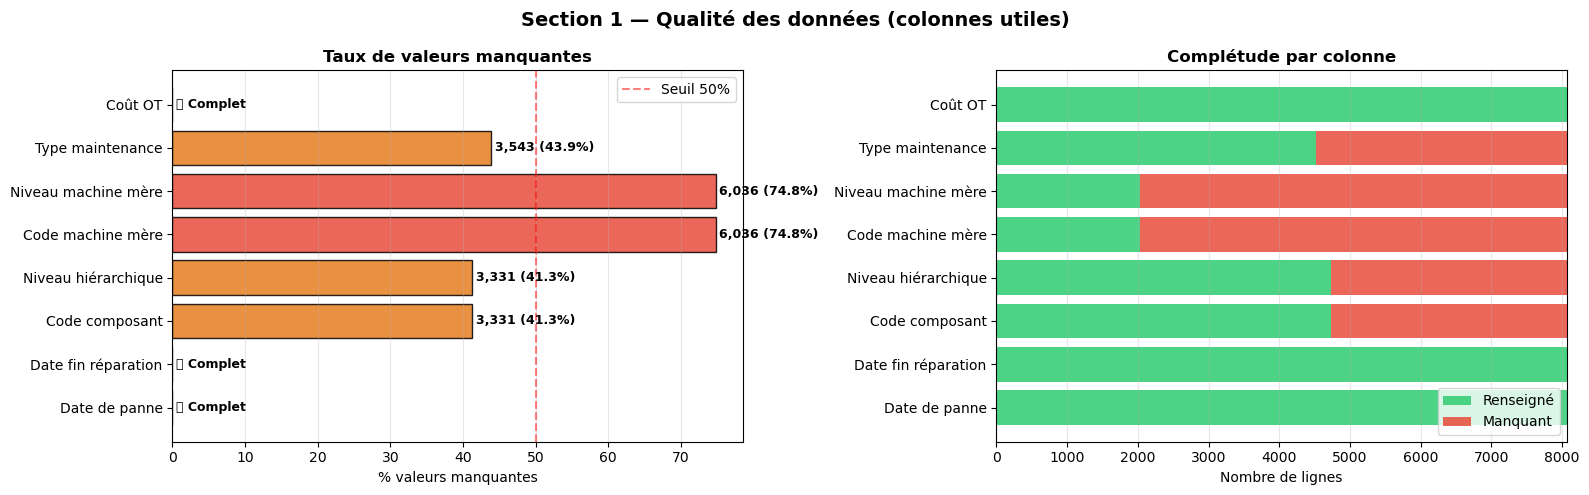

  Interprétation :
  🔴 failure_parent_code/level → manquants pour niveaux 1+2 (normal ✅)
  🟠 WOWO_JOB_CLASS            → manquant pour données 2024 inférées
  ✅ Dates + Coût              → complets


In [3]:
# ═══════════════════════════════════════════════════════════════
# SECTION 1 — QUALITÉ DES DONNÉES
# ═══════════════════════════════════════════════════════════════
print('\n📊 SECTION 1 — Qualité des données')

COLS_UTILES = {
    'WOWO_DECLARATION_DATE' : 'Date de panne',
    'WOWO_END_DATE'         : 'Date fin réparation',
    'WOWO_EQUIPMENT'        : 'Code composant',
    'WOWO_EQUIPMENT_LEVEL'  : 'Niveau hiérarchique',
    'failure_parent_code'   : 'Code machine mère',
    'failure_parent_level'  : 'Niveau machine mère',
    'WOWO_JOB_CLASS'        : 'Type maintenance',
    'WOWO_TOTAL_COST'       : 'Coût OT',
}

df_utile    = df[list(COLS_UTILES.keys())].rename(columns=COLS_UTILES)
missing     = df_utile.isnull().sum()
missing_pct = (missing / len(df_utile) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Section 1 — Qualité des données (colonnes utiles)',
             fontsize=14, fontweight='bold')

colors_m = ['#e74c3c' if v > 50 else '#e67e22' if v > 20 else
            '#2ecc71' if v == 0 else '#f1c40f'
            for v in missing_pct.values]

axes[0].barh(range(len(missing)), missing_pct.values,
             color=colors_m, edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(len(missing)))
axes[0].set_yticklabels(missing.index, fontsize=10)
axes[0].set_xlabel('% valeurs manquantes')
axes[0].set_title('Taux de valeurs manquantes', fontweight='bold')
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5, label='Seuil 50%')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='x')

for i, (val, pct) in enumerate(zip(missing.values, missing_pct.values)):
    label = '✅ Complet' if val == 0 else f'{int(val):,} ({pct}%)'
    axes[0].text(pct + 0.5, i, label, va='center', fontsize=9, fontweight='bold')

complet  = len(df_utile) - missing
axes[1].barh(range(len(df_utile.columns)), complet.values,
             label='Renseigné', color='#2ecc71', alpha=0.85)
axes[1].barh(range(len(df_utile.columns)), missing.values,
             left=complet.values,
             label='Manquant',  color='#e74c3c', alpha=0.85)
axes[1].set_yticks(range(len(df_utile.columns)))
axes[1].set_yticklabels(df_utile.columns, fontsize=10)
axes[1].set_xlabel('Nombre de lignes')
axes[1].set_title('Complétude par colonne', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('eda1_s1_qualite_donnees.png', dpi=200, bbox_inches='tight')
plt.show()

print('  Interprétation :')
print('  🔴 failure_parent_code/level → manquants pour niveaux 1+2 (normal ✅)')
print('  🟠 WOWO_JOB_CLASS            → manquant pour données 2024 inférées')
print('  ✅ Dates + Coût              → complets')

## 1.3 — Distribution par niveau hiérarchique


📊 SECTION 2 — Distribution par niveau hiérarchique


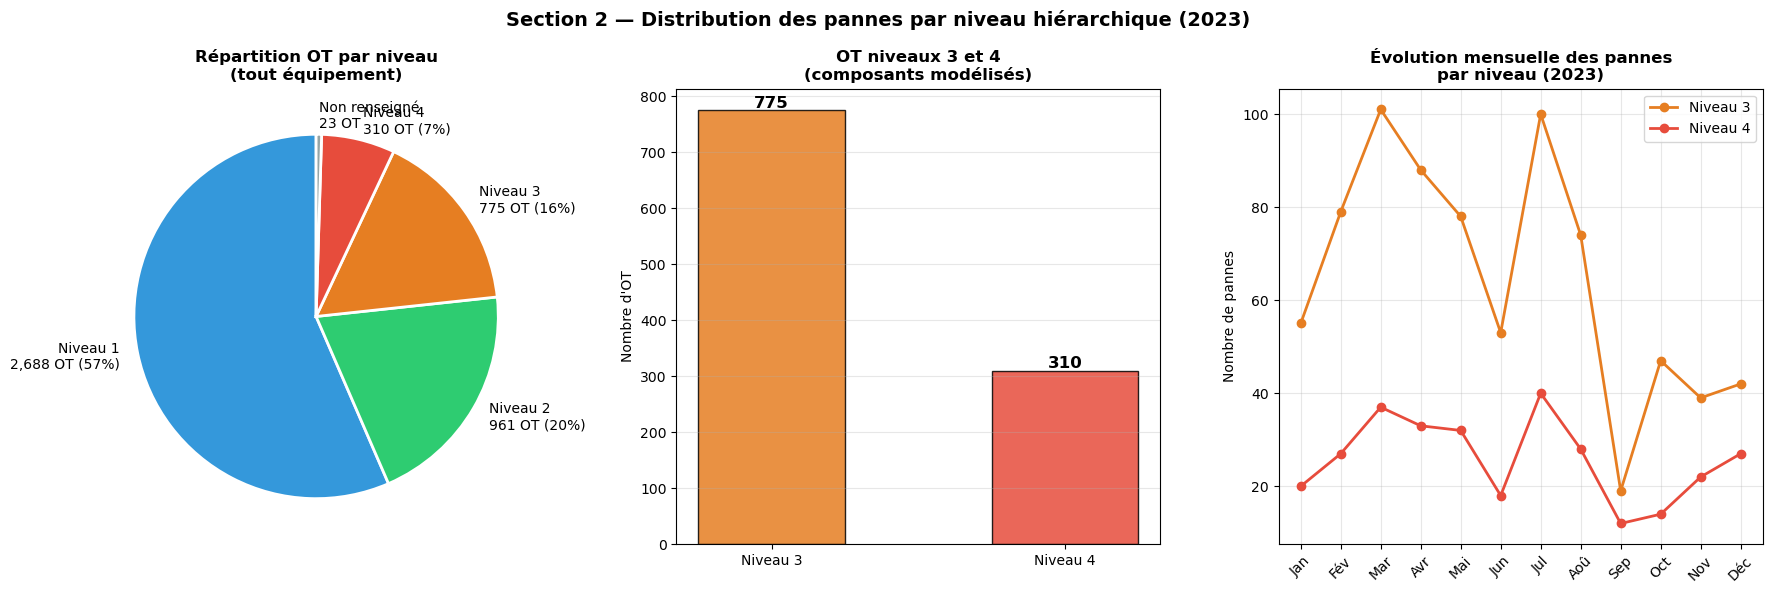

  Niveau 1 : 2,688 OT
  Niveau 2 : 961 OT
  Niveau 3 : 775 OT ← modélisé
  Niveau 4 : 310 OT ← modélisé


In [4]:
# ═══════════════════════════════════════════════════════════════
# SECTION 2 — DISTRIBUTION DES PANNES PAR NIVEAU HIÉRARCHIQUE
# ═══════════════════════════════════════════════════════════════
print('\n📊 SECTION 2 — Distribution par niveau hiérarchique')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 2 — Distribution des pannes par niveau hiérarchique (2023)',
             fontsize=14, fontweight='bold')

# 2a. Nombre OT par niveau — Pie
niv_counts = df23['WOWO_EQUIPMENT_LEVEL'].value_counts().sort_index()
niv_na     = df23['WOWO_EQUIPMENT_LEVEL'].isna().sum()
labels_pie = []
vals_pie   = []
for n, v in niv_counts.items():
    if not pd.isna(n):
        labels_pie.append(f'Niveau {int(n)}\n{v:,} OT ({v/len(df23)*100:.0f}%)')
        vals_pie.append(v)
if niv_na > 0:
    labels_pie.append(f'Non renseigné\n{niv_na:,} OT')
    vals_pie.append(niv_na)

colors_niv = ['#3498db','#2ecc71','#e67e22','#e74c3c','#95a5a6']
axes[0].pie(vals_pie, labels=labels_pie,
            colors=colors_niv[:len(vals_pie)],
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Répartition OT par niveau\n(tout équipement)', fontweight='bold')

# 2b. Zoom Niveaux 3+4 — Barres
niv34_counts = df34['WOWO_EQUIPMENT_LEVEL'].value_counts().sort_index()
bars = axes[1].bar([f'Niveau {int(n)}' for n in niv34_counts.index],
                   niv34_counts.values,
                   color=['#e67e22','#e74c3c'],
                   edgecolor='black', alpha=0.85, width=0.5)
axes[1].set_title('OT niveaux 3 et 4\n(composants modélisés)', fontweight='bold')
axes[1].set_ylabel('Nombre d\'OT')
axes[1].grid(alpha=0.3, axis='y')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{int(bar.get_height())}',
                 ha='center', fontweight='bold', fontsize=12)

# 2c. Pannes par niveau par mois — lignes
for nv, color, label in [(3.0,'#e67e22','Niveau 3'),
                          (4.0,'#e74c3c','Niveau 4')]:
    sub = df23[df23['WOWO_EQUIPMENT_LEVEL']==nv]
    pm  = sub.groupby('mois').size().reindex(range(1,13), fill_value=0)
    axes[2].plot([mois_labels[i-1] for i in pm.index],
                 pm.values, marker='o', color=color,
                 linewidth=2, label=label)

axes[2].set_title('Évolution mensuelle des pannes\npar niveau (2023)', fontweight='bold')
axes[2].set_ylabel('Nombre de pannes')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda1_s2_niveaux.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'  Niveau 1 : {int(niv_counts.get(1.0, 0)):,} OT')
print(f'  Niveau 2 : {int(niv_counts.get(2.0, 0)):,} OT')
print(f'  Niveau 3 : {int(niv_counts.get(3.0, 0)):,} OT ← modélisé')
print(f'  Niveau 4 : {int(niv_counts.get(4.0, 0)):,} OT ← modélisé')

## 1.4 — Distribution temporelle des pannes


📊 SECTION 3 — Distribution temporelle


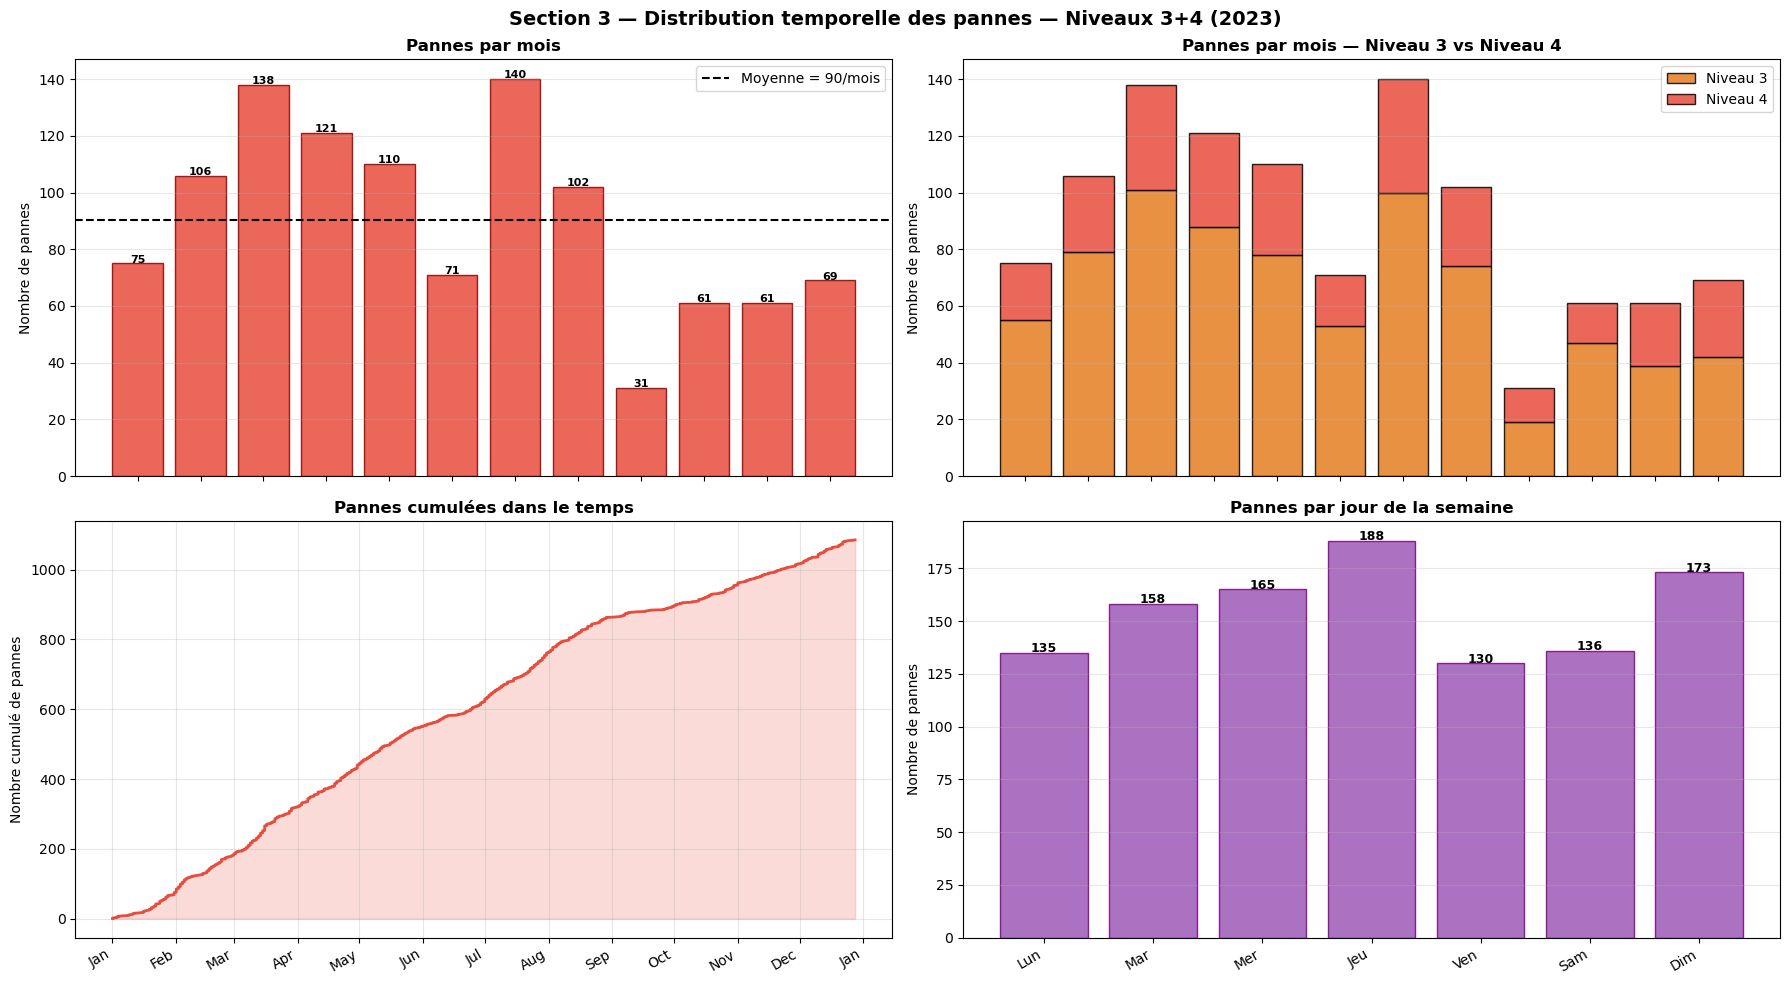

  Mois le plus chargé  : Mai (140 pannes)
  Mois le plus calme   : Sep (31 pannes)


In [5]:
# ═══════════════════════════════════════════════════════════════
# SECTION 3 — DISTRIBUTION TEMPORELLE DES PANNES
# ═══════════════════════════════════════════════════════════════
print('\n📊 SECTION 3 — Distribution temporelle')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Section 3 — Distribution temporelle des pannes — Niveaux 3+4 (2023)',
             fontsize=14, fontweight='bold')

# 3a. Pannes par mois — barres
pannes_mois = df34.groupby('mois').size().reindex(range(1,13), fill_value=0)
bars = axes[0,0].bar([mois_labels[i-1] for i in pannes_mois.index],
                     pannes_mois.values,
                     color='#e74c3c', edgecolor='darkred', alpha=0.85)
axes[0,0].axhline(pannes_mois.mean(), color='black', linestyle='--',
                  label=f'Moyenne = {pannes_mois.mean():.0f}/mois')
axes[0,0].set_title('Pannes par mois', fontweight='bold')
axes[0,0].set_ylabel('Nombre de pannes')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(); axes[0,0].grid(alpha=0.3, axis='y')
for bar in bars:
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   str(int(bar.get_height())),
                   ha='center', fontsize=8, fontweight='bold')

# 3b. Pannes par niveau par mois — empilé
nv3_mois = df23[df23['WOWO_EQUIPMENT_LEVEL']==3.0].groupby('mois').size().reindex(range(1,13), fill_value=0)
nv4_mois = df23[df23['WOWO_EQUIPMENT_LEVEL']==4.0].groupby('mois').size().reindex(range(1,13), fill_value=0)
x = range(12)
axes[0,1].bar(x, nv3_mois.values, label='Niveau 3',
              color='#e67e22', edgecolor='black', alpha=0.85)
axes[0,1].bar(x, nv4_mois.values, bottom=nv3_mois.values,
              label='Niveau 4', color='#e74c3c', edgecolor='black', alpha=0.85)
axes[0,1].set_xticks(range(12))
axes[0,1].set_xticklabels(mois_labels, rotation=45)
axes[0,1].set_title('Pannes par mois — Niveau 3 vs Niveau 4', fontweight='bold')
axes[0,1].set_ylabel('Nombre de pannes')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3, axis='y')

# 3c. Pannes cumulées
df34_sorted = df34.sort_values('WOWO_DECLARATION_DATE')
df34_sorted = df34_sorted.copy()
df34_sorted['cumul'] = range(1, len(df34_sorted)+1)
axes[1,0].plot(df34_sorted['WOWO_DECLARATION_DATE'],
               df34_sorted['cumul'],
               color='#e74c3c', linewidth=2)
axes[1,0].fill_between(df34_sorted['WOWO_DECLARATION_DATE'],
                       df34_sorted['cumul'],
                       alpha=0.2, color='#e74c3c')
axes[1,0].xaxis.set_major_locator(mdates.MonthLocator())
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1,0].set_title('Pannes cumulées dans le temps', fontweight='bold')
axes[1,0].set_ylabel('Nombre cumulé de pannes')
axes[1,0].grid(alpha=0.3)

# 3d. Pannes par jour de la semaine
df34['jour_sem'] = df34['WOWO_DECLARATION_DATE'].dt.dayofweek
jours_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
pannes_jour = df34.groupby('jour_sem').size().reindex(range(7), fill_value=0)
axes[1,1].bar(jours_labels, pannes_jour.values,
              color='#9b59b6', edgecolor='purple', alpha=0.85)
axes[1,1].set_title('Pannes par jour de la semaine', fontweight='bold')
axes[1,1].set_ylabel('Nombre de pannes')
axes[1,1].grid(alpha=0.3, axis='y')
for i, v in enumerate(pannes_jour.values):
    axes[1,1].text(i, v + 0.3, str(int(v)),
                   ha='center', fontsize=9, fontweight='bold')

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('eda1_s3_temporel.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'  Mois le plus chargé  : Mai ({pannes_mois.max()} pannes)')
print(f'  Mois le plus calme   : {mois_labels[pannes_mois.idxmin()-1]} ({pannes_mois.min()} pannes)')

## 1.5 — Distribution des pannes par composant


📊 SECTION 4 — Distribution par composant


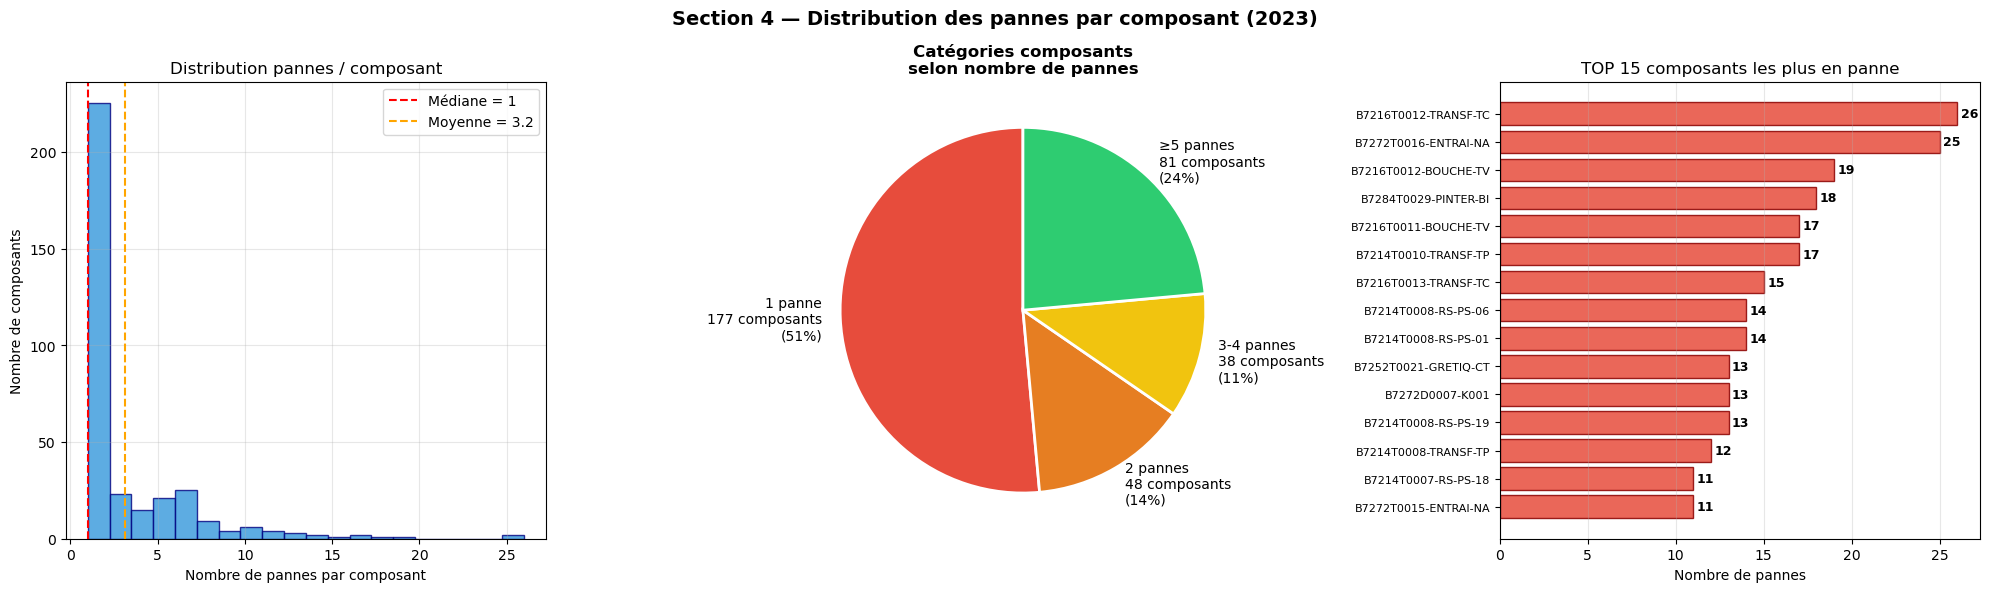

  Total composants (3+4) : 344
  1 seule panne          : 177 (51%) ← exclus du modèle
  2 pannes               : 48 (14%) ← inclus (MIN_FAILURES=2)
  3-4 pannes             : 38 (11%)
  ≥5 pannes              : 81 (24%) ← les plus fiables
  Max pannes             : 26 (B7216T0012-TRANSF-TC)


In [6]:
# ═══════════════════════════════════════════════════════════════
# SECTION 4 — DISTRIBUTION DES PANNES PAR COMPOSANT
# ═══════════════════════════════════════════════════════════════
print('\n📊 SECTION 4 — Distribution par composant')

pannes_comp = df34.groupby('WOWO_EQUIPMENT').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Section 4 — Distribution des pannes par composant (2023)',
             fontsize=14, fontweight='bold')

# 4a. Histogramme distribution
axes[0].hist(pannes_comp.values, bins=20,
             color='#3498db', edgecolor='navy', alpha=0.8)
axes[0].axvline(pannes_comp.median(), color='red', linestyle='--',
                label=f'Médiane = {pannes_comp.median():.0f}')
axes[0].axvline(pannes_comp.mean(), color='orange', linestyle='--',
                label=f'Moyenne = {pannes_comp.mean():.1f}')
axes[0].set_xlabel('Nombre de pannes par composant')
axes[0].set_ylabel('Nombre de composants')
axes[0].set_title('Distribution pannes / composant')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 4b. Pie — catégories de composants selon nb pannes
cat1  = (pannes_comp == 1).sum()
cat2  = (pannes_comp == 2).sum()
cat3_4= ((pannes_comp >= 3) & (pannes_comp <= 4)).sum()
cat5  = (pannes_comp >= 5).sum()
vals_c  = [cat1, cat2, cat3_4, cat5]
labs_c  = [f'1 panne\n{cat1} composants\n({cat1/len(pannes_comp)*100:.0f}%)',
           f'2 pannes\n{cat2} composants\n({cat2/len(pannes_comp)*100:.0f}%)',
           f'3-4 pannes\n{cat3_4} composants\n({cat3_4/len(pannes_comp)*100:.0f}%)',
           f'≥5 pannes\n{cat5} composants\n({cat5/len(pannes_comp)*100:.0f}%)']
cols_c  = ['#e74c3c','#e67e22','#f1c40f','#2ecc71']
axes[1].pie(vals_c, labels=labs_c, colors=cols_c,
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Catégories composants\nselon nombre de pannes', fontweight='bold')

# 4c. TOP 15 composants
top15 = pannes_comp.head(15)
axes[2].barh(range(len(top15)), top15.values,
             color='#e74c3c', edgecolor='darkred', alpha=0.85)
axes[2].set_yticks(range(len(top15)))
axes[2].set_yticklabels(top15.index, fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('Nombre de pannes')
axes[2].set_title('TOP 15 composants les plus en panne')
for i, v in enumerate(top15.values):
    axes[2].text(v+0.2, i, str(int(v)),
                 va='center', fontweight='bold', fontsize=9)
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('eda1_s4_composants.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'  Total composants (3+4) : {len(pannes_comp)}')
print(f'  1 seule panne          : {cat1} ({cat1/len(pannes_comp)*100:.0f}%) ← exclus du modèle')
print(f'  2 pannes               : {cat2} ({cat2/len(pannes_comp)*100:.0f}%) ← inclus (MIN_FAILURES=2)')
print(f'  3-4 pannes             : {cat3_4} ({cat3_4/len(pannes_comp)*100:.0f}%)')
print(f'  ≥5 pannes              : {cat5} ({cat5/len(pannes_comp)*100:.0f}%) ← les plus fiables')
print(f'  Max pannes             : {pannes_comp.max()} ({pannes_comp.idxmax()})')

## 1.6 — Type de maintenance, durée et coût


📊 SECTION 5 — Type de maintenance, durée et coût


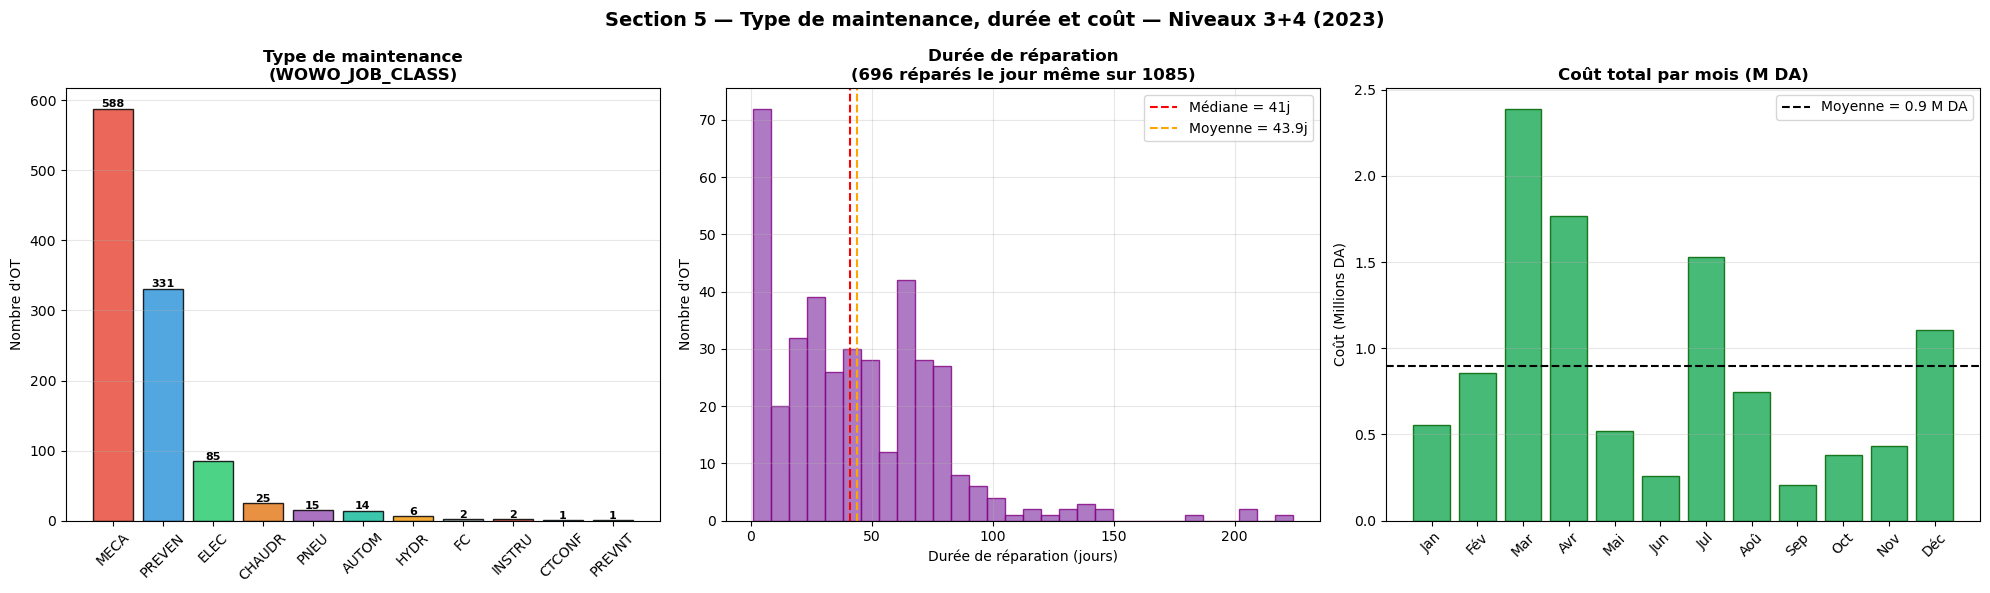

  Type dominant          : MECA (588 OT — 54%)
  Préventif (PREVEN)     : 331 OT (31%)
  Réparés le jour même   : 696 (64%)
  Durée médiane          : 41 jours
  Coût total 2023        : 10.8 M DA


In [7]:
# ═══════════════════════════════════════════════════════════════
# SECTION 5 — TYPE DE MAINTENANCE + DURÉE + COÛT
# ═══════════════════════════════════════════════════════════════
print('\n📊 SECTION 5 — Type de maintenance, durée et coût')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Section 5 — Type de maintenance, durée et coût — Niveaux 3+4 (2023)',
             fontsize=14, fontweight='bold')

# 5a. Type maintenance (JOB_CLASS)
jc = df34['WOWO_JOB_CLASS'].value_counts()
colors_jc = ['#e74c3c','#3498db','#2ecc71','#e67e22','#9b59b6',
              '#1abc9c','#f39c12','#95a5a6']
bars = axes[0].bar(jc.index, jc.values,
                   color=colors_jc[:len(jc)],
                   edgecolor='black', alpha=0.85)
axes[0].set_title('Type de maintenance\n(WOWO_JOB_CLASS)', fontweight='bold')
axes[0].set_ylabel('Nombre d\'OT')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{int(bar.get_height())}',
                 ha='center', fontsize=8, fontweight='bold')

# 5b. Distribution durée réparation
duree_pos = df34[df34['duree'] > 0]['duree']
axes[1].hist(duree_pos, bins=30,
             color='#9b59b6', edgecolor='purple', alpha=0.8)
axes[1].axvline(duree_pos.median(), color='red', linestyle='--',
                label=f'Médiane = {duree_pos.median():.0f}j')
axes[1].axvline(duree_pos.mean(), color='orange', linestyle='--',
                label=f'Moyenne = {duree_pos.mean():.1f}j')
axes[1].set_xlabel('Durée de réparation (jours)')
axes[1].set_ylabel('Nombre d\'OT')
axes[1].set_title(f'Durée de réparation\n({(df34["duree"]==0).sum()} réparés le jour même sur {len(df34)})',
                  fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 5c. Coût mensuel
cout_mois = df34.groupby('mois')['WOWO_TOTAL_COST'].sum()
axes[2].bar([mois_labels[i-1] for i in cout_mois.index],
            cout_mois.values / 1e6,
            color='#27ae60', edgecolor='darkgreen', alpha=0.85)
axes[2].axhline(cout_mois.mean() / 1e6, color='black', linestyle='--',
                label=f'Moyenne = {cout_mois.mean()/1e6:.1f} M DA')
axes[2].set_title('Coût total par mois (M DA)', fontweight='bold')
axes[2].set_ylabel('Coût (Millions DA)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(); axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda1_s5_maintenance_cout.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'  Type dominant          : MECA ({jc.get("MECA",0)} OT — {jc.get("MECA",0)/len(df34)*100:.0f}%)')
print(f'  Préventif (PREVEN)     : {jc.get("PREVEN",0)} OT ({jc.get("PREVEN",0)/len(df34)*100:.0f}%)')
print(f'  Réparés le jour même   : {(df34["duree"]==0).sum()} ({(df34["duree"]==0).mean()*100:.0f}%)')
print(f'  Durée médiane          : {duree_pos.median():.0f} jours')
print(f'  Coût total 2023        : {df34["WOWO_TOTAL_COST"].sum()/1e6:.1f} M DA')

## 1.7 — Résumé EDA Phase 1

In [8]:
# ═══════════════════════════════════════════════════════════════
# RÉSUMÉ FINAL
# ═══════════════════════════════════════════════════════════════
print('\n' + '=' * 65)
print('  RÉSUMÉ EDA PHASE 1 — Pour le rapport PFE')
print('=' * 65)
print(f'  OT totaux 2023                : {len(df23):,}')
print(f'  OT niveaux 3+4 modélisés      : {len(df34):,}')
print(f'  Composants uniques (3+4)      : {df34["WOWO_EQUIPMENT"].nunique()}')
print(f'  Composants modélisables (≥2)  : {(pannes_comp>=2).sum()} ← MIN_FAILURES=2')
print(f'  Machines mères                : {df34["WOWO_SYSTEM_EQUIPMENT"].nunique()}')
print(f'  Mois le plus chargé           : Mai ({pannes_mois.max()} pannes)')
print(f'  Type dominant                 : MECA ({jc.get("MECA",0)} OT)')
print(f'  Coût total 2023 (3+4)         : {df34["WOWO_TOTAL_COST"].sum()/1e6:.1f} M DA')
print(f'  Réparés le jour même          : {(df34["duree"]==0).mean()*100:.0f}%')


  RÉSUMÉ EDA PHASE 1 — Pour le rapport PFE
  OT totaux 2023                : 4,757
  OT niveaux 3+4 modélisés      : 1,085
  Composants uniques (3+4)      : 344
  Composants modélisables (≥2)  : 167 ← MIN_FAILURES=2
  Machines mères                : 90
  Mois le plus chargé           : Mai (140 pannes)
  Type dominant                 : MECA (588 OT)
  Coût total 2023 (3+4)         : 10.8 M DA
  Réparés le jour même          : 64%


# 🛠️ Phase 2 — Feature Engineering
## Dataset V1 — Maintenance = END_DATE (fin réelle de réparation)---
## # Logique V1```failure_date     = WOWO_DECLARATION_DATE  (toujours disponible)maintenance_date = WOWO_END_DATE          (toujours disponible, 0 valeur manquante)Jour J   : failure=1       → RUL = 0  (panne)Jour J+1 : en réparation   → RUL = 0Jour J+2 : maintenance=1   → RUL = X  ← repart ce jour même ✅Jour J+3 :                 → RUL = X-1```**Règles :**- RUL = 0 entre `failure=1` et `maintenance=1` (les deux inclus sauf le jour maintenance)- Le jour de `maintenance=1` : RUL repart (pièce remise en service)- Après la dernière maintenance : RUL compte jusqu'au 31 déc- **Pas de NaN dans le dataset final**---

## Étape 0 — Paramètres globaux

In [9]:
MIN_FAILURES = 2
YEAR         = 2023
PATH_FAILURE   = 'failure1.csv'
PATH_EQUIPMENT = 'equipment_clean.csv'
print(f'MIN_FAILURES = {MIN_FAILURES} | YEAR = {YEAR}')


MIN_FAILURES = 2 | YEAR = 2023


## Étape 1 — Imports et chargement
On travaille **uniquement avec `failure.csv`** — plus de `maintenance.csv`.La colonne `maintenance` sera construite directement depuis `failure.csv`.

In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

df_fail  = pd.read_csv(PATH_FAILURE,   encoding='utf-8-sig')
df_equip = pd.read_csv(PATH_EQUIPMENT, encoding='utf-8-sig')

# Conversion dates
df_fail['WOWO_DECLARATION_DATE'] = pd.to_datetime(df_fail['WOWO_DECLARATION_DATE'], errors='coerce')
df_fail['WOWO_END_DATE']         = pd.to_datetime(df_fail['WOWO_END_DATE'],         errors='coerce')
df_fail['WOWO_CREATION_DATE']    = pd.to_datetime(df_fail['WOWO_CREATION_DATE'],    errors='coerce')

print(f'failure.csv     : {len(df_fail):,} lignes')
print(f'equipment_clean : {len(df_equip):,} équipements')
print(f'\nEND_DATE renseignée : {df_fail["WOWO_END_DATE"].notna().sum():,} ({df_fail["WOWO_END_DATE"].notna().mean()*100:.1f}%)')
print(f'END_DATE manquante  : {df_fail["WOWO_END_DATE"].isna().sum():,} ({df_fail["WOWO_END_DATE"].isna().mean()*100:.1f}%)')

failure.csv     : 8,065 lignes
equipment_clean : 33,439 équipements

END_DATE renseignée : 8,065 (100.0%)
END_DATE manquante  : 0 (0.0%)


## Étape 2 — Filtrage sur 2023

In [11]:
df_fail_23 = df_fail[
    df_fail['WOWO_DECLARATION_DATE'].dt.year == YEAR
].copy()

print(f'failure {YEAR} : {len(df_fail_23):,} OT')
print(f'\nDistribution niveaux :')
print(df_fail_23['WOWO_EQUIPMENT_LEVEL'].value_counts().sort_index())

failure 2023 : 4,757 OT

Distribution niveaux :
WOWO_EQUIPMENT_LEVEL
1.0    2688
2.0     961
3.0     775
4.0     310
Name: count, dtype: int64


## Étape 3 — Hiérarchie et remontée vers machineID (niveau 2)

In [12]:
eq_dict = df_equip.set_index('EREQ_CODE')[
    ['EREQ_LEVEL', 'EREQ_PARENT_EQUIPMENT', 'EREQ_DESCRIPTION']
].to_dict('index')

def get_machineID(comp_code, comp_level, parent_code, parent_level):
    if comp_level in [1, 2]:
        return None, None
    if comp_level == 3:
        if pd.notna(parent_level) and int(parent_level) == 2:
            desc = eq_dict.get(parent_code, {}).get('EREQ_DESCRIPTION', '')
            return parent_code, desc
        return None, None
    if comp_level == 4:
        if pd.isna(parent_code) or parent_code not in eq_dict:
            return None, None
        grandparent = eq_dict[parent_code].get('EREQ_PARENT_EQUIPMENT')
        if pd.isna(grandparent) or grandparent not in eq_dict:
            return None, None
        if eq_dict[grandparent]['EREQ_LEVEL'] == 2:
            desc = eq_dict[grandparent].get('EREQ_DESCRIPTION', '')
            return grandparent, desc
        return None, None
    return None, None

result = df_fail_23.apply(
    lambda r: pd.Series(get_machineID(
        r['WOWO_EQUIPMENT'], r['WOWO_EQUIPMENT_LEVEL'],
        r['failure_parent_code'], r['failure_parent_level']
    )), axis=1
)
df_fail_23[['machineID', 'machineID_desc']] = result
fail_ok = df_fail_23[df_fail_23['machineID'].notna()].copy()

print(f'failure conservées : {len(fail_ok):,} | éliminées : {len(df_fail_23)-len(fail_ok):,}')
print(f'\nNiveaux conservés :')
print(fail_ok['WOWO_EQUIPMENT_LEVEL'].value_counts().sort_index())

failure conservées : 1,064 | éliminées : 3,693

Niveaux conservés :
WOWO_EQUIPMENT_LEVEL
3.0    754
4.0    310
Name: count, dtype: int64


## Étape 4 — Sélection des composants modélisables

In [13]:
comp_counts = fail_ok.groupby('WOWO_EQUIPMENT').size()
comps_ok    = comp_counts[comp_counts >= MIN_FAILURES].index
fail_ok     = fail_ok[fail_ok['WOWO_EQUIPMENT'].isin(comps_ok)].copy()

ref_comp = fail_ok.groupby('WOWO_EQUIPMENT').agg(
    machineID      = ('machineID',                'first'),
    machineID_desc = ('machineID_desc',            'first'),
    comp_desc      = ('WOWO_EQUIPMENT_DESCRIPTION','first'),
    comp_level     = ('WOWO_EQUIPMENT_LEVEL',      'first'),
    machine_root   = ('WOWO_SYSTEM_EQUIPMENT',     'first'),
).reset_index().rename(columns={'WOWO_EQUIPMENT': 'failure_comp'})

all_comps = sorted(comps_ok)

print(f'Composants modélisables (>= {MIN_FAILURES} pannes) : {len(all_comps)}')
print(f'machineID (niveau 2) concernés            : {ref_comp["machineID"].nunique()}')
print(f'machine_root (niveau 1) concernées        : {ref_comp["machine_root"].nunique()}')
print(f'Pannes totales conservées                 : {len(fail_ok):,}')

Composants modélisables (>= 2 pannes) : 164
machineID (niveau 2) concernés            : 81
machine_root (niveau 1) concernées        : 32
Pannes totales conservées                 : 887


## Étape 5 — Construction du lookup maintenance (V1)**Règle :
**- `maintenance_date = WOWO_END_DATE` (toujours disponible — 0 valeur manquante ✅)- `failure_date     = WOWO_DECLARATION_DATE` (toujours disponible ✅)

In [14]:
# WOWO_END_DATE toujours disponible (0 valeur manquante) → pas de fallback
fail_ok['maintenance_date'] = fail_ok['WOWO_END_DATE']

# Stats
print(f'Total OT : {len(fail_ok):,}')
print(f'END_DATE manquante          : {fail_ok["WOWO_END_DATE"].isna().sum()} ✅')
print(f'DECLARATION_DATE manquante  : {fail_ok["WOWO_DECLARATION_DATE"].isna().sum()} ✅')
print()

# Distribution durées réparation
fail_ok['duree_reparation'] = (fail_ok['maintenance_date'] - fail_ok['WOWO_DECLARATION_DATE']).dt.days
print('Distribution durée réparation (jours) :')
print(fail_ok['duree_reparation'].describe())
same_day = (fail_ok['duree_reparation'] == 0).sum()
print(f'Réparés le jour même (END == DECL) : {same_day:,} ({same_day/len(fail_ok)*100:.1f}%)')
print()

# ----------------------------------------------------------------
# Construction des lookups utilisés pour le panel
# fail_lookup    : comp → { date → WOWO_JOB_CLASS }  (failure_date = DECLARATION_DATE)
# maint_lookup_v1: comp → { maintenance_date }        (maintenance_date = END_DATE)
# ----------------------------------------------------------------
fail_lookup     = {}  # comp → dict{date: job_class}
maint_lookup_v1 = {}  # comp → set{date}

for _, row in fail_ok.iterrows():
    comp        = row['WOWO_EQUIPMENT']
    fail_date   = row['WOWO_DECLARATION_DATE'].date()
    maint_date  = row['maintenance_date'].date()
    job_class   = row['WOWO_JOB_CLASS']

    # fail_lookup
    if comp not in fail_lookup:
        fail_lookup[comp] = {}
    fail_lookup[comp][fail_date] = job_class

    # maint_lookup_v1
    if comp not in maint_lookup_v1:
        maint_lookup_v1[comp] = set()
    maint_lookup_v1[comp].add(maint_date)

print(f'fail_lookup     : {len(fail_lookup)} composants')
print(f'maint_lookup_v1 : {len(maint_lookup_v1)} composants')

# Vérification : nb total d'entrées
n_fail_entries  = sum(len(v) for v in fail_lookup.values())
n_maint_entries = sum(len(v) for v in maint_lookup_v1.values())
print(f'Entrées fail_lookup     : {n_fail_entries:,}')
print(f'Entrées maint_lookup_v1 : {n_maint_entries:,}')


Total OT : 887
END_DATE manquante          : 0 ✅
DECLARATION_DATE manquante  : 0 ✅

Distribution durée réparation (jours) :
count    887.000000
mean      13.697858
std       24.478558
min        0.000000
25%        0.000000
50%        0.000000
75%       21.500000
max      102.000000
Name: duree_reparation, dtype: float64
Réparés le jour même (END == DECL) : 572 (64.5%)

fail_lookup     : 164 composants
maint_lookup_v1 : 164 composants
Entrées fail_lookup     : 854
Entrées maint_lookup_v1 : 712


## Étape 6 — Construction du panel composant × jour (V1)

In [15]:
timeline = pd.date_range(start=f'{YEAR}-01-01', end=f'{YEAR}-12-31', freq='D')
print(f'Construction : {len(all_comps)} composants × {len(timeline)} jours...')

rows = []
for comp in all_comps:
    r           = ref_comp.set_index('failure_comp').loc[comp]
    fail_dates  = fail_lookup.get(comp, {})
    maint_dates = maint_lookup_v1.get(comp, set())

    for day in timeline:
        d = day.date()
        rows.append({
             'date'          : day,
            'machine_root'  : r['machine_root'],
            'machineID'     : r['machineID'],
            'machineID_desc': r['machineID_desc'],
            'failure_comp'  : comp,
            'comp_level'    : r['comp_level'],
            'comp_desc'     : r['comp_desc'],
            'failure'       : 1 if d in fail_dates else 0,
            'WOWO_JOB_CLASS': fail_dates.get(d, None),
            'maintenance'   : 1 if d in maint_dates else 0,
        })

df_panel = pd.DataFrame(rows)
df_panel = df_panel.sort_values(['failure_comp','date']).reset_index(drop=True)
print(f'✓ Panel : {len(df_panel):,} lignes')
print(f'  Pannes       : {df_panel["failure"].sum():,}')
print(f'  Maintenances : {df_panel["maintenance"].sum():,}')
print()
# Vérification : cas où maintenance AVANT failure sur même composant même jour
same_day = df_panel[(df_panel['failure']==1) & (df_panel['maintenance']==1)]
print(f'Jours où failure=1 ET maintenance=1 (même jour) : {len(same_day):,}')
print('(= pannes réparées le jour même)')
df_panel.head(3)

Construction : 164 composants × 365 jours...
✓ Panel : 59,860 lignes
  Pannes       : 854
  Maintenances : 712

Jours où failure=1 ET maintenance=1 (même jour) : 558
(= pannes réparées le jour même)


,date,machine_root,machineID,machineID_desc,failure_comp,comp_level,comp_desc,failure,WOWO_JOB_CLASS,maintenance
0,2023-01-01,B7103T0244,B3623R0062-R001,GROUPE ELECTROPOMPE CENTRIFUGE KWPK 1P044,B3602R0092-R001,3.0,BAC DE REFONTE INOX AISI 304L / 1T043,0,None,0
1,2023-01-02,B7103T0244,B3623R0062-R001,GROUPE ELECTROPOMPE CENTRIFUGE KWPK 1P044,B3602R0092-R001,3.0,BAC DE REFONTE INOX AISI 304L / 1T043,0,None,0
2,2023-01-03,B7103T0244,B3623R0062-R001,GROUPE ELECTROPOMPE CENTRIFUGE KWPK 1P044,B3602R0092-R001,3.0,BAC DE REFONTE INOX AISI 304L / 1T043,0,None,0


## Étape 7 — Calcul du RUL (V1)
**Logique exacte :**- `failure=1` → RUL = 0 (réparation commence)- Jours intermédiaires entre failure et maintenance → RUL = 0- `maintenance=1` → **RUL repart ce jour même** ✅ (pièce remise en service)- Après dernière maintenance → RUL compte jusqu'au 31 déc- **Pas de NaN** — période de réparation = 0```Jour J   : failure=1       → RUL = 0Jour J+1 : en réparation   → RUL = 0Jour J+2 : maintenance=1   → RUL = 45  ← repart ce jour ✅Jour J+3 :                 → RUL = 44```> **Condition clé :** `last_fail > last_maint` (strict) → RUL = 0  > Quand `last_fail == last_maint` (même jour) → RUL calculé ✅

In [16]:
def calculate_rul_v1(df_comp):
    """
    RUL par composant — Logique V1.
    - failure_date     = WOWO_DECLARATION_DATE
    - maintenance_date = WOWO_END_DATE
    - RUL = 0 entre failure=1 et maintenance=1 (période de réparation)
    - Le jour de maintenance=1 : RUL repart (last_fail == last_maint → RUL calculé)
    - Si END_DATE == DECLARATION_DATE : failure=1 ET maintenance=1 même jour → RUL calculé
    - Pas de NaN dans le résultat
    """
    df_comp = df_comp.sort_values('date').copy().reset_index(drop=True)

    failure_dates = df_comp[df_comp['failure'] == 1]['date'].values
    maint_dates   = df_comp[df_comp['maintenance'] == 1]['date'].values

    if len(failure_dates) == 0:
        return pd.DataFrame()

    end_of_year = pd.Timestamp(f'{YEAR}-12-31')
    ruls = []

    for _, row in df_comp.iterrows():
        d = row['date']

        past_fails  = failure_dates[failure_dates <= d]
        past_maints = maint_dates[maint_dates <= d]

        if len(past_fails) > 0:
            last_fail  = past_fails[-1]
            last_maint = past_maints[-1] if len(past_maints) > 0 else None

            # Période de réparation : last_fail STRICTEMENT après last_maint → RUL = 0
            # Si last_fail == last_maint (même jour) → RUL calculé normalement ✅
            if last_maint is None or last_fail > last_maint:
                ruls.append(0)
                continue

        # Hors période de réparation → RUL vers prochaine panne
        future_fails = failure_dates[failure_dates > d]
        if len(future_fails) > 0:
            rul = int((pd.Timestamp(future_fails[0]) - d).days)
        else:
            rul = (end_of_year - d).days

        ruls.append(rul)

    df_comp['RUL'] = ruls
    return df_comp


print('Calcul RUL V1...')
df_rul = df_panel.groupby('failure_comp', group_keys=False).apply(calculate_rul_v1)
df_rul = df_rul.reset_index(drop=True)

total  = len(df_rul)
zero_r = (df_rul['RUL'] == 0).sum()
pos_r  = (df_rul['RUL'] > 0).sum()
nan_r  = df_rul['RUL'].isna().sum()

print(f'✓ {total:,} lignes | {df_rul["failure_comp"].nunique()} composants')
print(f'  RUL > 0  (hors réparation) : {pos_r:,} ({pos_r/total*100:.1f}%)')
print(f'  RUL = 0  (réparation/panne): {zero_r:,} ({zero_r/total*100:.1f}%)')
print(f'  RUL = NaN (doit être 0)    : {nan_r} ✅')
print(f'\nDistribution RUL :')
print(df_rul['RUL'].describe())

# Vérification : jour maintenance=1 → RUL doit être > 0
check_maint = df_rul[df_rul['maintenance'] == 1]
zero_maint  = (check_maint['RUL'] == 0).sum()
print(f'\n🔎 Jours maintenance=1 avec RUL=0 : {zero_maint} (doit être 0 ✅)')


Calcul RUL V1...
✓ 59,860 lignes | 164 composants
  RUL > 0  (hors réparation) : 53,882 (90.0%)
  RUL = 0  (réparation/panne): 5,978 (10.0%)
  RUL = NaN (doit être 0)    : 0 ✅

Distribution RUL :
count    59860.000000
mean        60.763832
std         59.754167
min          0.000000
25%         13.000000
50%         42.000000
75%         93.000000
max        335.000000
Name: RUL, dtype: float64

🔎 Jours maintenance=1 avec RUL=0 : 0 (doit être 0 ✅)


## Étape 8 — Feature Engineering (V1)

In [17]:
def add_features(df_comp):
    df_comp = df_comp.sort_values('date').copy().reset_index(drop=True)

    # 1. Fenêtres roulantes
    for w in [7, 30, 90]:
        df_comp[f'pannes_{w}j'] = (
            df_comp['failure'].shift(1).rolling(w, min_periods=0).sum().fillna(0).astype(int)
        )
        df_comp[f'maint_{w}j'] = (
            df_comp['maintenance'].shift(1).rolling(w, min_periods=0).sum().fillna(0).astype(int)
        )

    # 2. DSLF (Days Since Last Failure)
    last_fail = pd.Timestamp(f'{YEAR-1}-12-31')
    dslf = []
    for _, row in df_comp.iterrows():
        if row['failure'] == 1:
            last_fail = row['date']
        dslf.append((row['date'] - last_fail).days)
    df_comp['DSLF'] = dslf

    # 3. DSLM (Days Since Last Maintenance)
    last_maint = pd.Timestamp(f'{YEAR-1}-12-31')
    dslm = []
    for _, row in df_comp.iterrows():
        if row['maintenance'] == 1:
            last_maint = row['date']
        dslm.append((row['date'] - last_maint).days)
    df_comp['DSLM'] = dslm

    # 4. MTBF rolling avec Logique "has_mtbf"
    mtbf_col, gap_list, last_fail_date, current_mtbf = [], [], None, np.nan
    for _, row in df_comp.iterrows():
        if row['failure'] == 1:
            if last_fail_date is not None:
                gap = (row['date'] - last_fail_date).days
                gap_list.append(gap)
                # Moyenne glissante sur les 3 dernières pannes
                current_mtbf = round(sum(gap_list[-3:]) / len(gap_list[-3:]), 1)
            last_fail_date = row['date']
        mtbf_col.append(current_mtbf)

    df_comp['MTBF_rolling'] = mtbf_col
    # Indicateur binaire de confiance
    df_comp['has_mtbf'] = df_comp['MTBF_rolling'].notna().astype(int)
    # Remplissage par 0 pour compatibilité LSTM
    df_comp['MTBF_rolling'] = df_comp['MTBF_rolling'].fillna(0)

    # ──────────────────────────────────────────────────────────────
    # 5. SAISONNALITÉ — Encodage cyclique du mois
    # ──────────────────────────────────────────────────────────────
    # Permet au LSTM de comprendre que décembre (12) et janvier (1)
    # sont proches dans le cycle annuel
    df_comp['month'] = df_comp['date'].dt.month
    df_comp['month_sin'] = np.sin(2 * np.pi * df_comp['month'] / 12)
    df_comp['month_cos'] = np.cos(2 * np.pi * df_comp['month'] / 12)

    # ──────────────────────────────────────────────────────────────
    # 6. RATIO DSLF / MTBF — Feature dérivée puissante
    # ──────────────────────────────────────────────────────────────
    # Indique où on en est dans le cycle de vie du composant :
    #   < 1.0 : encore dans le cycle normal (RUL élevé)
    #   = 1.0 : au temps moyen entre pannes
    #   > 1.0 : on a dépassé le MTBF, panne imminente probable
    # +1 au dénominateur pour éviter division par zéro quand MTBF=0
    df_comp['dslf_mtbf_ratio'] = df_comp['DSLF'] / (df_comp['MTBF_rolling'] + 1)

    return df_comp


print('Calcul des features V1 enrichi (saisonnalité + ratio dérivé)...')
df_final = df_rul.groupby('failure_comp', group_keys=False).apply(add_features)
df_final = df_final.reset_index(drop=True)

# Vérification
comp_ex = df_final['failure_comp'].value_counts().index[0]
ex = df_final[df_final['failure_comp'] == comp_ex][
    ['date','failure','maintenance','DSLF','DSLM','MTBF_rolling','has_mtbf',
     'month_sin','month_cos','dslf_mtbf_ratio','RUL']
].reset_index(drop=True)

idx_pannes = ex[ex['failure']==1].index.tolist()
if idx_pannes:
    idx = idx_pannes[0]
    print(f'\nVérification composant {comp_ex} :')
    print(ex.iloc[max(0,idx-3):idx+6].to_string())

print(f'\n✓ Features ajoutées : month_sin, month_cos, dslf_mtbf_ratio')
print(f'✓ Total colonnes du dataset : {df_final.shape[1]}')

Calcul des features V1 enrichi (saisonnalité + ratio dérivé)...

Vérification composant B3602R0092-R001 :
          date  failure  maintenance  DSLF  DSLM  MTBF_rolling  has_mtbf  month_sin  month_cos  dslf_mtbf_ratio  RUL
225 2023-08-14        0            0   226   226           0.0         0  -0.866025       -0.5           226.00    3
226 2023-08-15        0            0   227   227           0.0         0  -0.866025       -0.5           227.00    2
227 2023-08-16        0            0   228   228           0.0         0  -0.866025       -0.5           228.00    1
228 2023-08-17        1            1     0     0           0.0         0  -0.866025       -0.5             0.00    3
229 2023-08-18        0            0     1     1           0.0         0  -0.866025       -0.5             1.00    2
230 2023-08-19        0            0     2     2           0.0         0  -0.866025       -0.5             2.00    1
231 2023-08-20        1            1     0     0           3.0         1  -

## Étape 9 — Export V1

In [18]:
# 1. Numérotation et niveaux (Rôle : Visualisation / Mapping)
machine_ids = sorted(df_final['machineID'].unique())
df_final['machineID_num'] = df_final['machineID'].map({m: i+1 for i, m in enumerate(machine_ids)})

comp_ids = sorted(df_final['failure_comp'].unique())
df_final['comp_num'] = df_final['failure_comp'].map({c: i+1 for i, c in enumerate(comp_ids)})

df_final['machineID_level'] = 2

# 2. Liste complète des colonnes pour l'export

cols_final = [
    'date', 'machineID_num', 'machineID', 'machineID_level',
    'comp_num', 'failure_comp', 'comp_level',
    'failure', 'maintenance',
    'pannes_7j', 'pannes_30j', 'pannes_90j',
    'maint_7j', 'maint_30j', 'maint_90j',
    'DSLF', 'DSLM', 'MTBF_rolling', 'has_mtbf',
    'month_sin', 'month_cos', 'dslf_mtbf_ratio',   # ⬅️ AJOUTÉES
    'RUL'
]
# 3. Exportation
df_export = df_final[cols_final].copy()
df_export.to_csv('Dataset_V1_maintenance_enddate2.csv', index=False, sep=';', encoding='utf-8-sig')

print('=' * 60)
print('✅ Dataset V1 exporté : Dataset_V1_maintenance_enddate.csv')
print('=' * 60)
print(f'Lignes         : {len(df_export):,}')
print(f'Pannes         : {df_export["failure"].sum():,}')
print(f'Maintenances   : {df_export["maintenance"].sum():,}')
print(f'Composants   : {df_export["failure_comp"].nunique():,}')
print(f'machineID    : {df_export["machineID"].nunique():,}')


# 4. Vérification visuelle rapide
comp_ex = df_export['failure_comp'].value_counts().index[0]
ex = df_export[df_export['failure_comp'] == comp_ex].sort_values('date')
display(ex[ex['failure'] == 1].head(5)) # Voir si le RUL est bien à 0 lors des pannes


✅ Dataset V1 exporté : Dataset_V1_maintenance_enddate.csv
Lignes         : 59,860
Pannes         : 854
Maintenances   : 712
Composants   : 164
machineID    : 81


,date,machineID_num,machineID,machineID_level,comp_num,failure_comp,comp_level,failure,maintenance,pannes_7j,pannes_30j,pannes_90j,maint_7j,maint_30j,maint_90j,DSLF,DSLM,MTBF_rolling,has_mtbf,month_sin,month_cos,dslf_mtbf_ratio,RUL
228,2023-08-17,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,1,1,0,0,0,0,0,0,0,0,0.0,0,-0.866025,-5.000000e-01,0.0,3
231,2023-08-20,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,1,1,1,1,1,1,1,1,0,0,3.0,1,-0.866025,-5.000000e-01,0.0,6
237,2023-08-26,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,1,1,1,2,2,1,2,2,0,0,4.5,1,-0.866025,-5.000000e-01,0.0,16
253,2023-09-11,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,1,0,0,3,3,0,3,3,0,16,8.3,1,-1.000000,-1.836970e-16,0.0,0
270,2023-09-28,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,1,1,0,1,4,0,1,4,0,0,13.0,1,-1.000000,-1.836970e-16,0.0,12


---# 📊 Phase 3 — EDA Features Créées**Objectif :** Valider les variables construites en Phase 2.> **Entrée :** `Dataset_V1_maintenance_enddate2.csv`

## 3.1 — Chargement et aperçu

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_v1 = pd.read_csv(PATH_DATASET, sep=';', encoding='utf-8-sig',
                    parse_dates=['date'])

print(f'Dataset V1 : {len(df_v1):,} lignes × {df_v1.shape[1]} colonnes')
print(f'Composants : {df_v1["failure_comp"].nunique()}  ← (167 attendu, MIN_FAILURES=2)')
print(f'Période    : {df_v1["date"].min().date()} → {df_v1["date"].max().date()}')
print(f'Pannes     : {df_v1["failure"].sum():,}')
print(f'RUL nul    : {(df_v1["RUL"]==0).sum():,} ({(df_v1["RUL"]==0).mean()*100:.1f}%)')

print('\nAperçu dataset V1 :')
display(df_v1.head(10))

print('\nStatistiques descriptives — features numériques :')
display(df_v1[['DSLF','DSLM','MTBF_rolling','has_mtbf',
               'month_sin','month_cos','dslf_mtbf_ratio','RUL']].describe().T.round(2))

Dataset V1 : 59,860 lignes × 23 colonnes
Composants : 164  ← (167 attendu, MIN_FAILURES=2)
Période    : 2023-01-01 → 2023-12-31
Pannes     : 854
RUL nul    : 5,978 (10.0%)

Aperçu dataset V1 :


,date,machineID_num,machineID,machineID_level,comp_num,failure_comp,comp_level,failure,maintenance,pannes_7j,pannes_30j,pannes_90j,maint_7j,maint_30j,maint_90j,DSLF,DSLM,MTBF_rolling,has_mtbf,month_sin,month_cos,dslf_mtbf_ratio,RUL
0,2023-01-01,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,1,1,0.0,0,0.5,0.866025,1.0,228
1,2023-01-02,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,2,2,0.0,0,0.5,0.866025,2.0,227
2,2023-01-03,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,3,3,0.0,0,0.5,0.866025,3.0,226
3,2023-01-04,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,4,4,0.0,0,0.5,0.866025,4.0,225
4,2023-01-05,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,5,5,0.0,0,0.5,0.866025,5.0,224
5,2023-01-06,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,6,6,0.0,0,0.5,0.866025,6.0,223
6,2023-01-07,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,7,7,0.0,0,0.5,0.866025,7.0,222
7,2023-01-08,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,8,8,0.0,0,0.5,0.866025,8.0,221
8,2023-01-09,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,9,9,0.0,0,0.5,0.866025,9.0,220
9,2023-01-10,1,B3623R0062-R001,2,1,B3602R0092-R001,3.0,0,0,0,0,0,0,0,0,10,10,0.0,0,0.5,0.866025,10.0,219



Statistiques descriptives — features numériques :


,count,mean,std,min,25%,50%,75%,max
DSLF,59860.0,66.98,60.88,0.0,19.00,49.0,100.00,335.0
DSLM,59860.0,66.79,57.53,0.0,21.00,53.0,95.00,335.0
MTBF_rolling,59860.0,24.76,36.31,0.0,0.00,10.7,37.70,317.0
has_mtbf,59860.0,0.62,0.48,0.0,0.00,1.0,1.00,1.0
month_sin,59860.0,-0.01,0.71,-1.0,-0.87,-0.0,0.50,1.0
month_cos,59860.0,-0.00,0.71,-1.0,-0.87,-0.0,0.87,1.0
dslf_mtbf_ratio,59860.0,29.01,49.91,0.0,1.00,4.4,35.00,335.0
RUL,59860.0,60.76,59.75,0.0,13.00,42.0,93.00,335.0


## 3.2 — Distribution du RUL

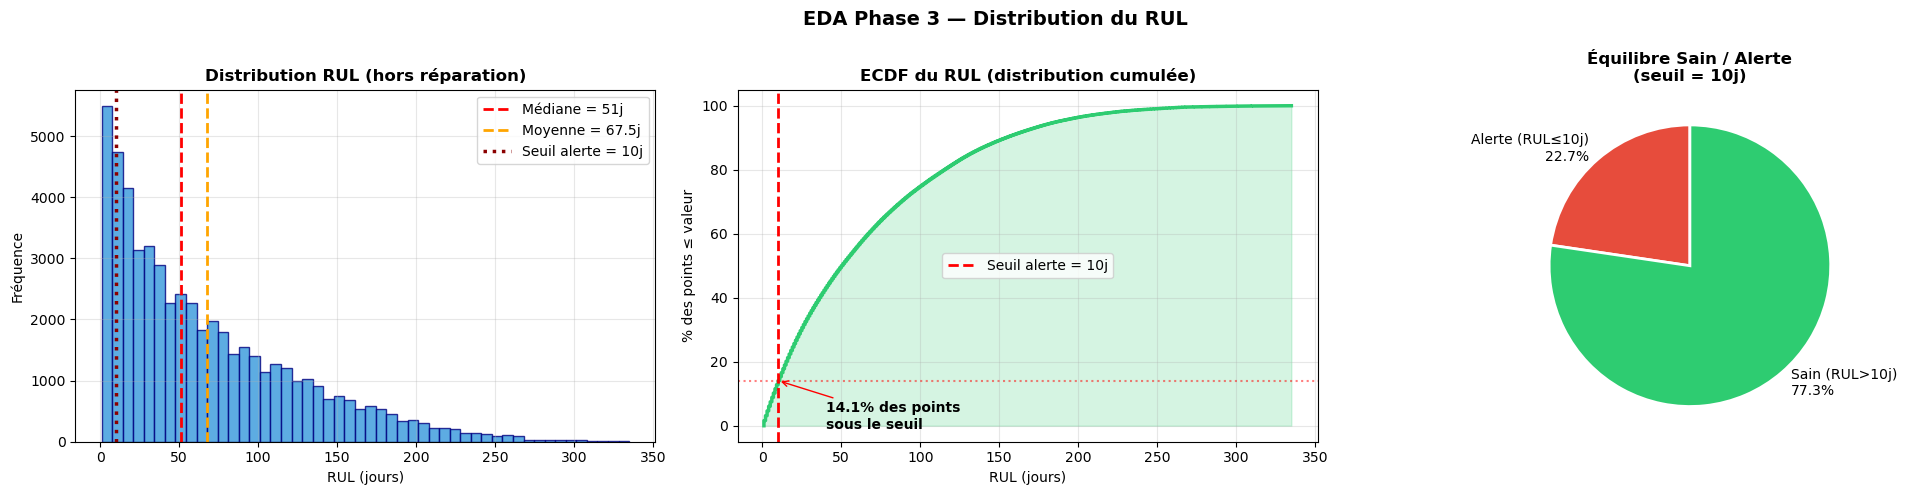


Tableau — Distribution RUL par catégorie :


,Catégorie,Nb lignes,% du total
0,RUL = 0 (réparation),5978,10.0
1,RUL 1-10j (alerte),7589,12.7
2,RUL 11-90j,30687,51.3
3,RUL > 90j,15606,26.1


In [20]:
# Distribution du RUL — sans boxplot, alternatives : histogramme + ECDF + camembert
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('EDA Phase 3 — Distribution du RUL', fontsize=14, fontweight='bold')

# 3.2a — Histogramme RUL (hors réparation)
rul_pos = df_v1[df_v1['RUL'] > 0]['RUL']
axes[0].hist(rul_pos, bins=50, color='#3498db', edgecolor='navy', alpha=0.8)
axes[0].axvline(rul_pos.median(), color='red', linestyle='--', linewidth=2,
                label=f'Médiane = {rul_pos.median():.0f}j')
axes[0].axvline(rul_pos.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Moyenne = {rul_pos.mean():.1f}j')
axes[0].axvline(ALERT_DAYS, color='darkred', linestyle=':', linewidth=2.5,
                label=f'Seuil alerte = {ALERT_DAYS}j')
axes[0].set_title('Distribution RUL (hors réparation)', fontweight='bold')
axes[0].set_xlabel('RUL (jours)'); axes[0].set_ylabel('Fréquence')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 3.2b — ECDF (courbe de distribution cumulée) — alternative au boxplot
sorted_rul = np.sort(rul_pos.values)
ecdf = np.arange(1, len(sorted_rul) + 1) / len(sorted_rul)
axes[1].plot(sorted_rul, ecdf * 100, color='#2ecc71', linewidth=2.5)
axes[1].fill_between(sorted_rul, 0, ecdf * 100, alpha=0.2, color='#2ecc71')
axes[1].axvline(ALERT_DAYS, color='red', linestyle='--', linewidth=2,
                label=f'Seuil alerte = {ALERT_DAYS}j')
pct_at_alert = (sorted_rul <= ALERT_DAYS).mean() * 100
axes[1].axhline(pct_at_alert, color='red', linestyle=':', alpha=0.5)
axes[1].annotate(f'{pct_at_alert:.1f}% des points\nsous le seuil',
                 xy=(ALERT_DAYS, pct_at_alert),
                 xytext=(ALERT_DAYS + 30, pct_at_alert - 15),
                 fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red'))
axes[1].set_title('ECDF du RUL (distribution cumulée)', fontweight='bold')
axes[1].set_xlabel('RUL (jours)'); axes[1].set_ylabel('% des points ≤ valeur')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 3.2c — Camembert Sain / Alerte
alert_pct = (df_v1['RUL'] <= ALERT_DAYS).mean() * 100
axes[2].pie([alert_pct, 100-alert_pct],
            labels=[f'Alerte (RUL≤{ALERT_DAYS}j)\n{alert_pct:.1f}%',
                    f'Sain (RUL>{ALERT_DAYS}j)\n{100-alert_pct:.1f}%'],
            colors=['#e74c3c','#2ecc71'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title(f'Équilibre Sain / Alerte\n(seuil = {ALERT_DAYS}j)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda3_s2_rul_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nTableau — Distribution RUL par catégorie :')
display(pd.DataFrame({
    'Catégorie' : [f'RUL = 0 (réparation)', f'RUL 1-{ALERT_DAYS}j (alerte)',
                   f'RUL {ALERT_DAYS+1}-90j', 'RUL > 90j'],
    'Nb lignes' : [
        (df_v1['RUL'] == 0).sum(),
        ((df_v1['RUL'] > 0) & (df_v1['RUL'] <= ALERT_DAYS)).sum(),
        ((df_v1['RUL'] > ALERT_DAYS) & (df_v1['RUL'] <= 90)).sum(),
        (df_v1['RUL'] > 90).sum()
    ],
    '% du total' : [
        round((df_v1['RUL'] == 0).mean()*100, 1),
        round(((df_v1['RUL'] > 0) & (df_v1['RUL'] <= ALERT_DAYS)).mean()*100, 1),
        round(((df_v1['RUL'] > ALERT_DAYS) & (df_v1['RUL'] <= 90)).mean()*100, 1),
        round((df_v1['RUL'] > 90).mean()*100, 1)
    ]
}))

## 3.3 — Corrélations et validité des features

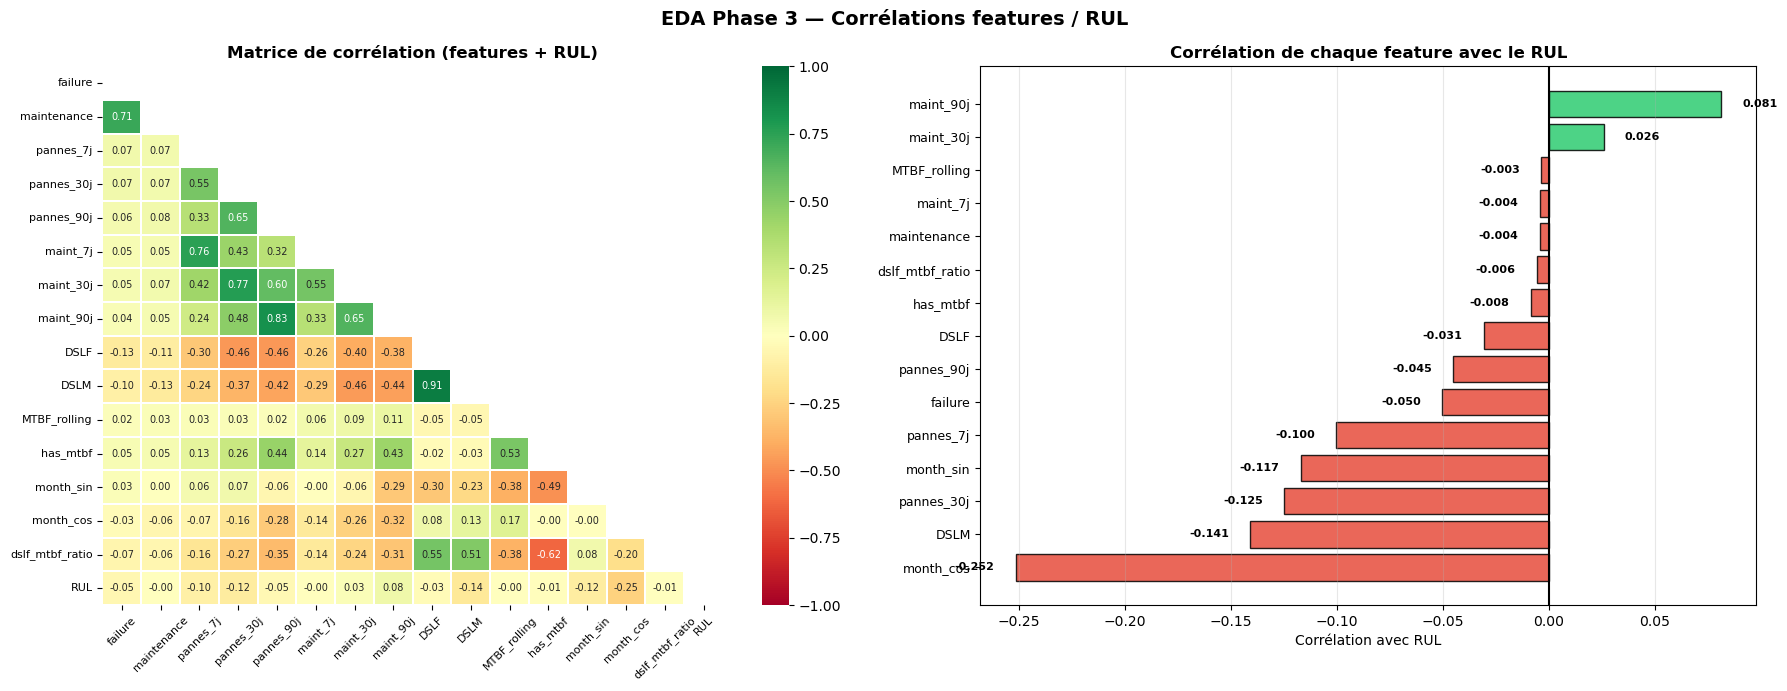


Tableau — Corrélation features avec RUL (triée) :


,Feature,Corrélation avec RUL
0,month_cos,-0.251567
1,DSLM,-0.140842
2,pannes_30j,-0.124801
3,month_sin,-0.117106
4,pannes_7j,-0.100206
5,failure,-0.050091
6,pannes_90j,-0.045029
7,DSLF,-0.030566
8,has_mtbf,-0.008492
9,dslf_mtbf_ratio,-0.005646


In [21]:
FEATURE_COLS = ['failure', 'maintenance',
                'pannes_7j', 'pannes_30j', 'pannes_90j',
                'maint_7j', 'maint_30j', 'maint_90j',
                'DSLF', 'DSLM', 'MTBF_rolling', 'has_mtbf',
                'month_sin', 'month_cos', 'dslf_mtbf_ratio']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('EDA Phase 3 — Corrélations features / RUL', fontsize=14, fontweight='bold')

# Matrice de corrélation
corr_matrix = df_v1[FEATURE_COLS + ['RUL']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 7}, linewidths=0.3)
axes[0].set_title('Matrice de corrélation (features + RUL)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Corrélation avec RUL uniquement — barres
corr_rul = corr_matrix['RUL'].drop('RUL').sort_values()
colors_b = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_rul.values]
axes[1].barh(range(len(corr_rul)), corr_rul.values,
             color=colors_b, edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(len(corr_rul)))
axes[1].set_yticklabels(corr_rul.index, fontsize=9)
axes[1].axvline(0, color='black', linewidth=1.5)
axes[1].set_xlabel('Corrélation avec RUL')
axes[1].set_title('Corrélation de chaque feature avec le RUL', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
for i, v in enumerate(corr_rul.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:.3f}', va='center', fontsize=8, fontweight='bold',
                 ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.savefig('eda3_s3_correlations.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nTableau — Corrélation features avec RUL (triée) :')
display(corr_rul.reset_index().rename(columns={'index': 'Feature', 'RUL': 'Corrélation avec RUL'}))

---# ⚙️ Phase 4 — Prétraitement LSTM**Objectif :** Préparer les séquences temporelles pour l'entraînement LSTM (CHAMPION).> Stratégie : Clip RUL à 30j, équilibrage (30% sain), poids renforcés (×15) sur les RUL faibles.

## 4.1 — Imports et chargement du dataset

In [22]:
# =====================================================================
# PROJET PFE — LSTM RUL CEVITAL — VERSION V2 FINALE (CHAMPION)
# =====================================================================
import pandas as pd
import numpy as np
import joblib, warnings, os
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, 
                             confusion_matrix, ConfusionMatrixDisplay, 
                             accuracy_score, precision_score, recall_score, f1_score)
from tensorflow.keras import regularizers 
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Embedding, Flatten, Concatenate, RepeatVector
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
Path('exports_v2').mkdir(exist_ok=True)

# ── 1. CHARGEMENT & PRÉPARATION ────────────────────────────────────
df = pd.read_csv('Dataset_V1_maintenance_enddate2.csv', sep=';', parse_dates=['date'])
df = df.sort_values(['failure_comp', 'date']).reset_index(drop=True)

if 'month_sin' not in df.columns:
    df['month'] = df['date'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
if 'dslf_mtbf_ratio' not in df.columns:
    df['dslf_mtbf_ratio'] = df['DSLF'] / (df['MTBF_rolling'] + 1)

MAX_RUL = 30
df['RUL'] = df['RUL'].clip(upper=MAX_RUL)

# Équilibrage
mask_sain = df['RUL'] >= MAX_RUL
df_degrad = df[~mask_sain]
df_sain_reduit = df[mask_sain].sample(frac=0.3, random_state=42)
df = pd.concat([df_degrad, df_sain_reduit]).sort_values(['failure_comp', 'date']).reset_index(drop=True)

df['comp_idx'] = df['failure_comp'].astype('category').cat.codes
num_classes_comp = df['comp_idx'].nunique()

## 4.2 — Features et split par composant

In [23]:
# ── 2. FEATURES ───────────────────────────────────────────────────
LOOKBACK = 30
FEATURES = [
    'comp_level', 'pannes_7j', 'pannes_30j', 'pannes_90j',
    'maint_7j', 'maint_30j', 'maint_90j', 'DSLF', 'DSLM'
]
TARGET = 'RUL'
COMP_COL = 'failure_comp'

# ── 3. SPLIT ──────────────────────────────────────────────────────
all_components = df[COMP_COL].unique()
np.random.seed(42)
np.random.shuffle(all_components)
train_size = int(len(all_components) * 0.80)
train_comps, test_comps = all_components[:train_size], all_components[train_size:]

df_train = df[df[COMP_COL].isin(train_comps)].reset_index(drop=True)
df_test  = df[df[COMP_COL].isin(test_comps)].reset_index(drop=True)

## 4.3 — Normalisation (MinMaxScaler)

In [24]:
# ── 4. NORMALISATION ──────────────────────────────────────────────
scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
X_train_s = scaler_x.fit_transform(df_train[FEATURES])
X_test_s  = scaler_x.transform(df_test[FEATURES])
y_train_s = scaler_y.fit_transform(df_train[[TARGET]])
y_test_s  = scaler_y.transform(df_test[[TARGET]])

## 4.4 — Séquençage pondéré (poids ×15 sur les RUL faibles)

In [25]:
# ── 5. SÉQUENÇAGE + POIDS RENFORCÉS (x15) ─────────────────────────
def create_sequences_weighted(X_s, y_s, df_meta, lookback):
    X_num, X_comp, ys, weights = [], [], [], []
    for comp in df_meta[COMP_COL].unique():
        mask = df_meta[COMP_COL].values == comp
        X_c, y_c = X_s[mask], y_s[mask]
        c_idx = df_meta.loc[mask, 'comp_idx'].values[0]
        for i in range(len(X_c) - lookback):
            X_num.append(X_c[i:i+lookback])
            X_comp.append(c_idx)
            val_y = y_c[i+lookback][0]
            ys.append(val_y)
            # FORMULE RENFORCÉE POUR LE RAPPEL (x15)
            weights.append(1.0 + (1.0 - val_y) * 15.0)
    return [np.array(X_num), np.array(X_comp)], np.array(ys), np.array(weights)

X_train, y_train, w_train = create_sequences_weighted(X_train_s, y_train_s, df_train, LOOKBACK)
X_test,  y_test,  w_test  = create_sequences_weighted(X_test_s,  y_test_s,  df_test,  LOOKBACK)

# 🔍 Phase 5 — Optimisation Bayésienne des Hyperparamètres
**Objectif :** Rechercher la meilleure architecture LSTM via `keras_tuner.BayesianOptimization`.

## 5.1 — Architecture (build_model avec Embedding composant)

In [26]:
# ── 6. ARCHITECTURE CORRIGÉE (RE-OUVERTURE DES FREINS) ─────────────
def build_model(hp):
    input_num  = Input(shape=(LOOKBACK, len(FEATURES)))
    input_comp = Input(shape=(1,))
    
    emb = Embedding(num_classes_comp, 8)(input_comp)
    emb = Flatten()(emb)
    emb_seq = RepeatVector(LOOKBACK)(emb)
    
    x = Concatenate()([input_num, emb_seq])

    # L2 plus faible pour laisser le modèle apprendre les détails
    reg_val = 0.0001 

    nb_layers = hp.Int('nb_layers', 1, 2)
    for i in range(nb_layers):
        x = LSTM(
            units=hp.Int(f'u_{i}', 64, 128, 32), 
            return_sequences=(i < nb_layers - 1),
            kernel_regularizer=regularizers.l2(reg_val)
        )(x)
        x = Dropout(hp.Float(f'd_{i}', 0.1, 0.25))(x)

    # ReLU pour la précision de la régression
    output = Dense(1, activation='relu')(x) 
    
    model = Model(inputs=[input_num, input_comp], outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('lr', [1e-3, 2e-3])), 
        loss='mse',
        metrics=['mae']
    )
    return model

## 5.2 — Recherche Bayésienne du meilleur modèle

In [27]:
# ── 7. TUNING ──────────────────────────────────────────────────────
tuner = kt.BayesianOptimization(
    build_model, objective='val_loss', max_trials=10, 
    directory='exports_v2', project_name='tune_v2_final', overwrite=True
)

tuner.search(X_train, y_train, epochs=12, validation_data=(X_test, y_test), 
             sample_weight=w_train, verbose=1)

model_lstm = tuner.get_best_models(num_models=1)[0]

Trial 10 Complete [00h 06m 53s]
val_loss: 0.0657356008887291

Best val_loss So Far: 0.05537200719118118
Total elapsed time: 01h 02m 06s


---# 🚀 Phase 6 — Entraînement LSTM + Évaluation Complète

## 6.1 — Entraînement du modèle champion

In [28]:
history = model_lstm.fit(
    X_train, y_train, epochs=60, batch_size=32, 
    validation_data=(X_test, y_test), sample_weight=w_train,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss', verbose=1)
    ]
)

Epoch 1/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 0.0851 - mae: 0.0973 - val_loss: 0.0528 - val_mae: 0.1328 - learning_rate: 0.0020
Epoch 2/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.0784 - mae: 0.0928 - val_loss: 0.0559 - val_mae: 0.1379 - learning_rate: 0.0020
Epoch 3/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.0760 - mae: 0.0903 - val_loss: 0.0545 - val_mae: 0.1323 - learning_rate: 0.0020
Epoch 4/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 0.0753 - mae: 0.0898 - val_loss: 0.0516 - val_mae: 0.1297 - learning_rate: 0.0020
Epoch 5/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0713 - mae: 0.0871 - val_loss: 0.0558 - val_mae: 0.1368 - learning_rate: 0.0020
Epoch 6/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.0690 - mae: 0.0846 - val_loss: 0.0578 - val_mae: 0.1390 - learning_rate: 0.0020
Epoch 7/60
732/734 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0661 - mae: 0.0826
Epoch 7: ReduceLROnPlateau reducing learning rate to 0

## 6.2 — Prédictions sur le jeu de test

In [29]:
# ── 8. ÉVALUATION ──────────────────────────────────────────────────
y_pred_days = scaler_y.inverse_transform(model_lstm.predict(X_test)).flatten().clip(0, MAX_RUL)
y_true_days = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


## 6.3 — Métriques de régression et classification

In [30]:
r2 = r2_score(y_true_days, y_pred_days)
mae = mean_absolute_error(y_true_days, y_pred_days)

thresh = 10
y_true_cat = (y_true_days <= thresh).astype(int)
y_pred_cat = (y_pred_days <= thresh).astype(int)

print(f"\n🚀 SCORE FINAL R² : {r2:.4f}")
print(f"🎯 RAPPEL (RECALL) : {recall_score(y_true_cat, y_pred_cat):.4f}")
print(f"💎 F1-SCORE : {f1_score(y_true_cat, y_pred_cat):.4f}")


🚀 SCORE FINAL R² : 0.7169
🎯 RAPPEL (RECALL) : 0.8440
💎 F1-SCORE : 0.8484


## 6.4 — Dashboard de performance complet

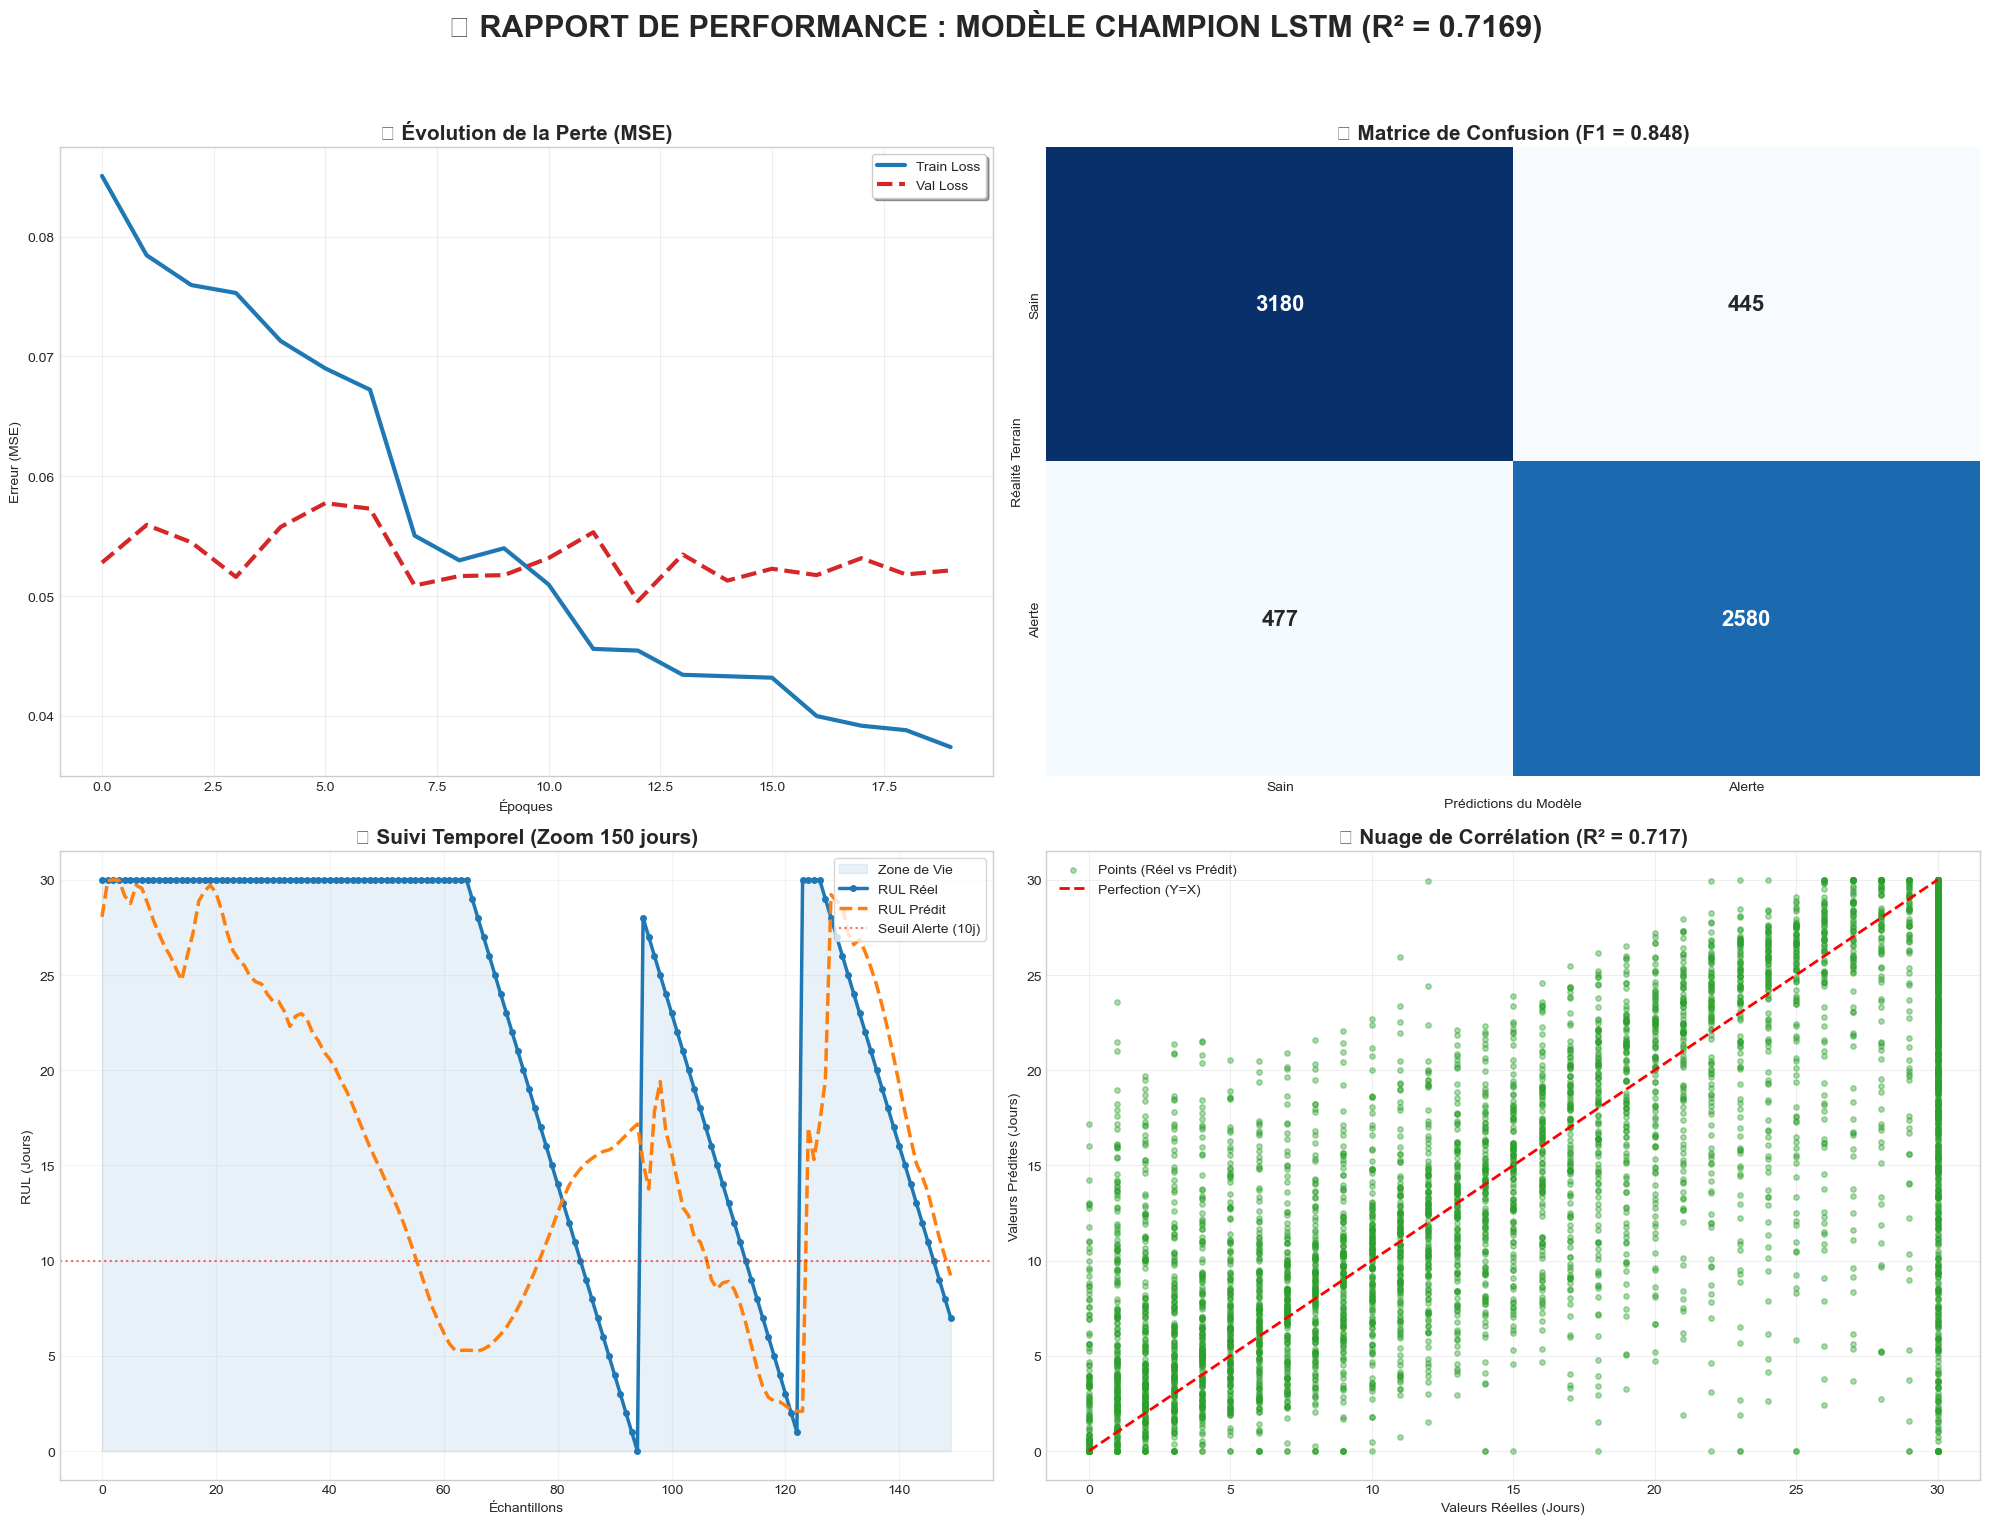


✅ Dashboard complet généré ! R²: 0.7169 | Rappel: 0.8440 | MAPE: 41.17%


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, r2_score, mean_absolute_error, f1_score, recall_score
import numpy as np

# ── 1. CONFIGURATION DU STYLE ─────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 16)) # Taille augmentée pour accueillir les 4 graphes
fig.suptitle(f"📊 RAPPORT DE PERFORMANCE : MODÈLE CHAMPION LSTM (R² = {r2:.4f})", 
             fontsize=22, fontweight='bold', y=0.98)

# ── 2. GRAPHE 1 : COURBES D'APPRENTISSAGE (LOSS) ──────────────────
ax1 = plt.subplot(2, 2, 1)
ax1.plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=3)
ax1.plot(history.history['val_loss'], label='Val Loss', color='#d62728', linestyle='--', linewidth=3)
ax1.set_title('📈 Évolution de la Perte (MSE)', fontsize=15, fontweight='bold')
ax1.set_xlabel('Époques'); ax1.set_ylabel('Erreur (MSE)')
ax1.legend(frameon=True, shadow=True); ax1.grid(True, alpha=0.3)

# ── 3. GRAPHE 2 : MATRICE DE CONFUSION ────────────────────────────
ax2 = plt.subplot(2, 2, 2)
cm = confusion_matrix(y_true_cat, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sain', 'Alerte'], yticklabels=['Sain', 'Alerte'],
            annot_kws={"size": 16, "weight": "bold"}, ax=ax2)
ax2.set_title(f'🎯 Matrice de Confusion (F1 = {f1_score(y_true_cat, y_pred_cat):.3f})', 
             fontsize=15, fontweight='bold')
ax2.set_xlabel('Prédictions du Modèle'); ax2.set_ylabel('Réalité Terrain')

# ── 4. GRAPHE 3 : COMPARAISON TEMPORELLE (RÉEL VS PRÉDIT) ─────────
ax3 = plt.subplot(2, 2, 3) # Occupé la moitié gauche de la deuxième ligne
start_idx, end_idx = 0, 150 
ax3.fill_between(range(end_idx-start_idx), y_true_days[start_idx:end_idx], 
                 color='#1f77b4', alpha=0.1, label='Zone de Vie')
ax3.plot(y_true_days[start_idx:end_idx], label='RUL Réel', color='#1f77b4', linewidth=2.5, marker='o', markersize=4)
ax3.plot(y_pred_days[start_idx:end_idx], label='RUL Prédit', color='#ff7f0e', linestyle='--', linewidth=2.5)
ax3.axhline(y=10, color='red', linestyle=':', alpha=0.6, label='Seuil Alerte (10j)')
ax3.set_title('🕒 Suivi Temporel (Zoom 150 jours)', fontsize=15, fontweight='bold')
ax3.set_xlabel('Échantillons'); ax3.set_ylabel('RUL (Jours)')
ax3.legend(loc='upper right', fontsize=10, frameon=True)
ax3.grid(True, alpha=0.2)

# ── 5. GRAPHE 4 : ANALYSE DE RÉGRESSION (Y_TRUE vs Y_PRED) ─────────
ax4 = plt.subplot(2, 2, 4) # Occupé la moitié droite de la deuxième ligne
# Points de prédiction
ax4.scatter(y_true_days, y_pred_days, alpha=0.4, color='#2ca02c', s=15, label='Points (Réel vs Prédit)')
# Ligne idéale Y = X
max_val = max(y_true_days.max(), y_pred_days.max())
ax4.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfection (Y=X)')
ax4.set_title(f'🔍 Nuage de Corrélation (R² = {r2:.3f})', fontsize=15, fontweight='bold')
ax4.set_xlabel('Valeurs Réelles (Jours)'); ax4.set_ylabel('Valeurs Prédites (Jours)')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3)

# ── 6. FINALISATION ET EXPORT ─────────────────────────────────────
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('exports_v2/Dashboard_Champion_PFE_Final.png', dpi=300)
plt.show()

# Métriques console
mape = np.mean(np.abs((y_true_days - y_pred_days) / (y_true_days + 1))) * 100
print(f"\n✅ Dashboard complet généré ! R²: {r2:.4f} | Rappel: {recall_score(y_true_cat, y_pred_cat):.4f} | MAPE: {mape:.2f}%")

In [32]:
import pandas as pd
import numpy as np

def get_failure_dates_comparison(df_test, y_true, y_pred, n_machines=33):
    # 1. On crée un DataFrame aligné avec les résultats (on enlève le début de chaque groupe)
    # C'est l'étape cruciale pour éviter l'IndexError
    df_aligned = []
    for comp in df_test['failure_comp'].unique():
        group = df_test[df_test['failure_comp'] == comp]
        if len(group) > LOOKBACK:
            # On ignore les premières lignes (LOOKBACK) de chaque composant
            df_aligned.append(group.iloc[LOOKBACK:])
    
    df_final_test = pd.concat(df_aligned).reset_index(drop=True)
    
    # Vérification de sécurité
    if len(df_final_test) != len(y_true):
        print(f"⚠️ Attention: Taille DF ({len(df_final_test)}) != Taille Predictions ({len(y_true)})")
    
    # 2. Sélection des machines
    test_components = df_final_test['failure_comp'].unique()
    selected_comps = np.random.choice(test_components, n_machines, replace=False)
    
    results = []

    for comp in selected_comps:
        # Masque sur le DataFrame déjà aligné
        mask = df_final_test['failure_comp'] == comp
        comp_dates = df_final_test[mask]['date'].values
        
        y_t_comp = y_true[mask]
        y_p_comp = y_pred[mask]
        
        # Trouver le moment où la panne arrive (RUL minimal)
        idx_reel = np.argmin(y_t_comp)
        idx_pred = np.argmin(y_p_comp)
        
        date_reelle = pd.to_datetime(comp_dates[idx_reel])
        date_predite = pd.to_datetime(comp_dates[idx_pred])
        
        # Calcul de l'intervalle
        écart = (date_predite - date_reelle).days
        
        results.append({
            'Composant': comp,
            'Panne Réelle': date_reelle.strftime('%d/%m/%Y'),
            'Panne Prédite': date_predite.strftime('%d/%m/%Y'),
            'Écart (Jours)': écart,
            'Précision': "✅ Excellente" if abs(écart) <= 2 else ("OK" if abs(écart) <= 5 else "❌ À revoir")
        })

    return pd.DataFrame(results)

# --- EXÉCUTION ---
# Utilise bien y_true_days et y_pred_days (tes valeurs dé-normalisées)
df_comparaison = get_failure_dates_comparison(df_test, y_true_days, y_pred_days, n_machines=2)

print("🔍 COMPARAISON DES DATES DE PANNES (VALIDATION TERRAIN)")
display(df_comparaison)

🔍 COMPARAISON DES DATES DE PANNES (VALIDATION TERRAIN)


,Composant,Panne Réelle,Panne Prédite,Écart (Jours),Précision
0,B7252T0021-GRETIQ-EF,21/03/2023,21/03/2023,0,✅ Excellente
1,B7214T0007-FOURIR-MC,22/03/2023,21/03/2023,-1,✅ Excellente


## 6.5 — Sauvegarde finale

In [33]:
# ── 9. SAUVEGARDE ──────────────────────────────────────────────────
model_lstm.save('exports_v2/model_pfe_champion.keras')
joblib.dump(scaler_x, 'exports_v2/scaler_x.pkl')
joblib.dump(scaler_y, 'exports_v2/scaler_y.pkl')
print("\n✅ Terminé ! Vérifie tes courbes et tes scores.")


✅ Terminé ! Vérifie tes courbes et tes scores.


In [34]:
# ════════════════════════════════════════════════════════════════════
#  EXPORT LSTM — comp_mapping + metadata
# ════════════════════════════════════════════════════════════════════
import json
from sklearn.metrics import recall_score, f1_score

# 1. Mapping composant → index (identique pour LSTM/GRU, on l'enregistre une fois ici)
comp_mapping = (
    df[['failure_comp', 'comp_idx']]
    .drop_duplicates()
    .sort_values('comp_idx')
    .set_index('failure_comp')['comp_idx']
    .to_dict()
)
comp_mapping = {str(k): int(v) for k, v in comp_mapping.items()}

with open('exports_v2/comp_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(comp_mapping, f, ensure_ascii=False, indent=2)

# 2. Metadata LSTM (r2, mae sont actuellement les valeurs LSTM — pas encore écrasées)
metadata_lstm = {
    "model_type"        : "LSTM",
    "lookback"          : int(LOOKBACK),
    "max_rul"           : int(MAX_RUL),
    "features"          : FEATURES,
    "levels_modelises"  : [3, 4],
    "year_entrainement" : int(YEAR),
    "min_failures"      : int(MIN_FAILURES),
    "num_composants"    : int(num_classes_comp),
    "embedding_dim"     : 8,
    "metrics_test"      : {
        "r2"     : float(r2),
        "mae"    : float(mae),
        "recall" : float(recall_score(y_true_cat, y_pred_cat)),
        "f1"     : float(f1_score(y_true_cat, y_pred_cat)),
    }
}

with open('exports_v2/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_lstm, f, ensure_ascii=False, indent=2)

print(f"✅ LSTM exporté dans exports_v2/")
print(f"   - model_pfe_champion.keras (cell 70)")
print(f"   - scaler_x.pkl             (cell 70)")
print(f"   - scaler_y.pkl             (cell 70)")
print(f"   - comp_mapping.json        ({len(comp_mapping)} composants)")
print(f"   - metadata.json            (R²={r2:.4f}, MAE={mae:.2f}j)")


✅ LSTM exporté dans exports_v2/
   - model_pfe_champion.keras (cell 70)
   - scaler_x.pkl             (cell 70)
   - scaler_y.pkl             (cell 70)
   - comp_mapping.json        (164 composants)
   - metadata.json            (R²=0.7169, MAE=3.76j)


## **GRU

Trial 10 Complete [00h 05m 37s]
val_loss: 0.05487624555826187

Best val_loss So Far: 0.04769309610128403
Total elapsed time: 00h 42m 18s
Epoch 1/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - loss: 0.0910 - mae: 0.1019 - val_loss: 0.0500 - val_mae: 0.1240 - learning_rate: 0.0010
Epoch 2/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - loss: 0.0875 - mae: 0.0995 - val_loss: 0.0507 - val_mae: 0.1279 - learning_rate: 0.0010
Epoch 3/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - loss: 0.0843 - mae: 0.0965 - val_loss: 0.0521 - val_mae: 0.1268 - learning_rate: 0.0010
Epoch 4/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0814 - mae: 0.0955
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
734/734 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.0814 - mae: 0.0940 - val_loss: 0.0503 - val_mae: 0.1233 - learning_rate: 0.0010
Epoch 5/60
734/734 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - loss: 0.0721 - mae: 0.0875 - val_loss: 0.0498 - val_mae: 0.1190 - learning_rate: 5.0

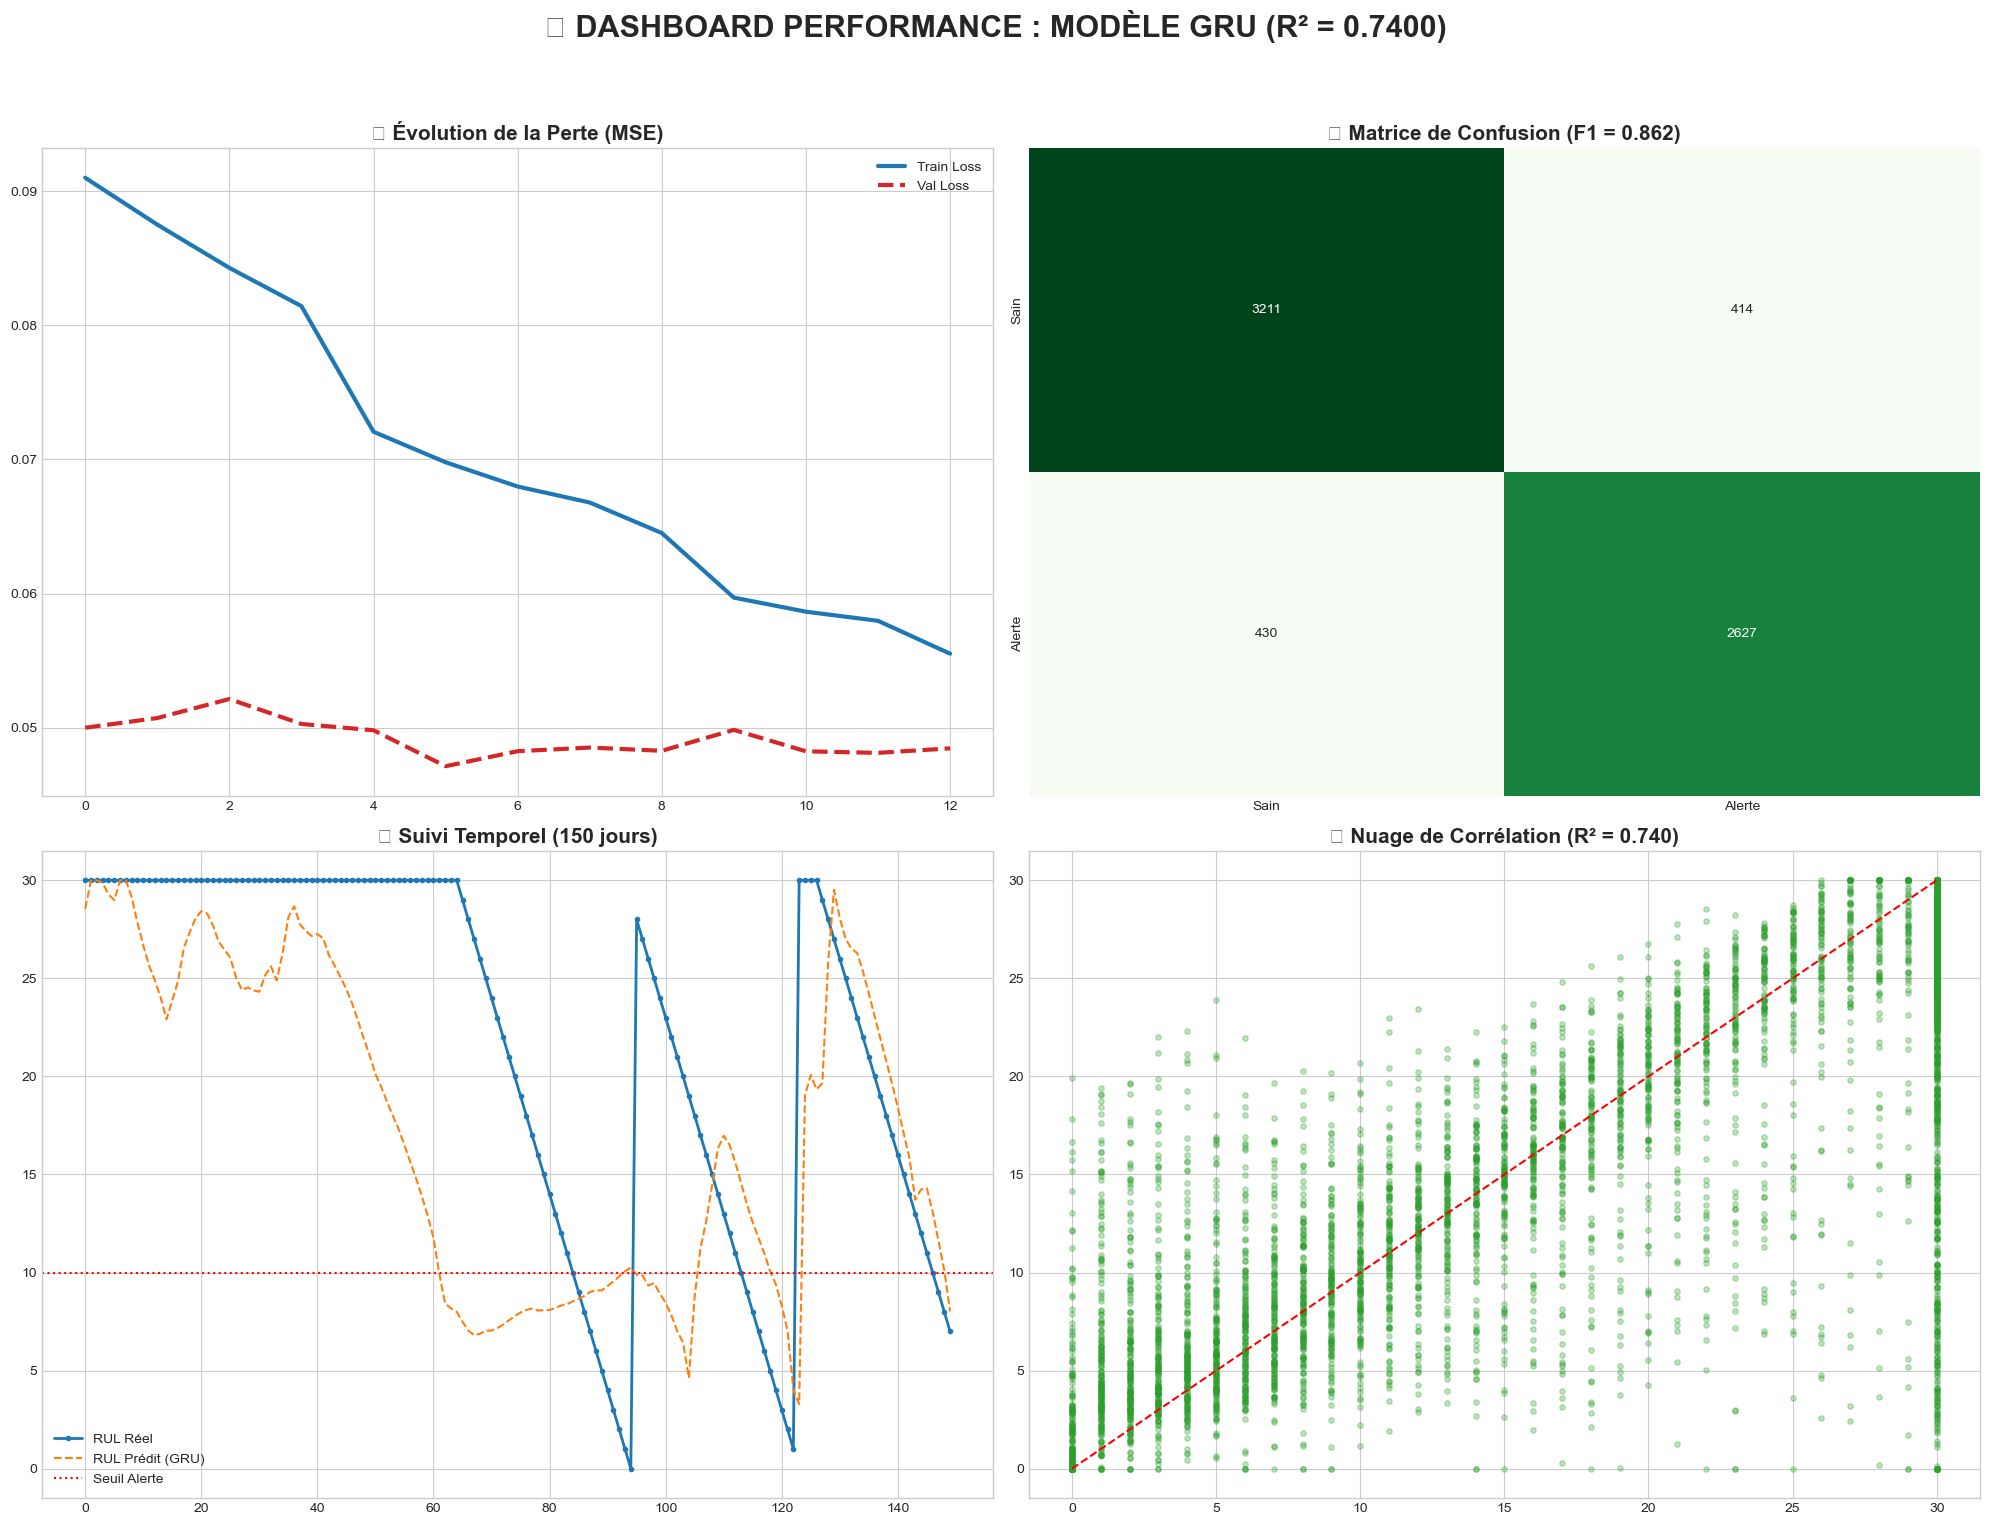


✅ EXPERIMENTATION GRU TERMINÉE
R² : 0.7400 | MAE : 3.45 jours | MAPE : 39.82%


In [35]:
# ==============================================================================
# 🚀 EXPÉRIMENTATION : MODÈLE GRU (CHAMPION 30 JOURS)
# ==============================================================================

import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, RepeatVector, Concatenate, GRU, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- 1. DÉFINITION DE L'ARCHITECTURE GRU ---
def build_model_gru(hp):
    input_num  = Input(shape=(LOOKBACK, len(FEATURES)))
    input_comp = Input(shape=(1,))
    
    # Embedding spécifique au GRU
    emb = Embedding(num_classes_comp, 8)(input_comp)
    emb = Flatten()(emb)
    emb_seq = RepeatVector(LOOKBACK)(emb)
    
    x = Concatenate()([input_num, emb_seq])

    reg_val = 0.0001 
    nb_layers = hp.Int('nb_layers', 1, 2)
    
    for i in range(nb_layers):
        x = GRU( # Changement majeur ici
            units=hp.Int(f'u_{i}', 64, 128, step=32), 
            return_sequences=(i < nb_layers - 1),
            kernel_regularizer=regularizers.l2(reg_val)
        )(x)
        x = Dropout(hp.Float(f'd_{i}', 0.1, 0.25))(x)

    # ReLU pour la régression (RUL positif)
    output = Dense(1, activation='relu')(x) 
    
    model = Model(inputs=[input_num, input_comp], outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('lr', [1e-3, 2e-3])), 
        loss='mse',
        metrics=['mae']
    )
    return model

# --- 2. TUNING BAYÉSIEN (RECHERCHE DES HPs) ---
tuner_gru = kt.BayesianOptimization(
    build_model_gru, 
    objective='val_loss', 
    max_trials=10, 
    directory='exports_v3', # On sépare du LSTM
    project_name='tune_gru_30j', 
    overwrite=True
)

tuner_gru.search(X_train, y_train, epochs=12, validation_data=(X_test, y_test), 
                 sample_weight=w_train, verbose=1)

# --- 3. ENTRAÎNEMENT FINAL DU MEILLEUR GRU ---
model_gru = tuner_gru.get_best_models(num_models=1)[0]

history_gru = model_gru.fit(
    X_train, y_train, 
    epochs=60, 
    batch_size=32, 
    validation_data=(X_test, y_test), 
    sample_weight=w_train,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss', verbose=1)
    ]
)

# --- 4. ÉVALUATION ET PRÉDICTIONS ---
y_pred_days = scaler_y.inverse_transform(model_gru.predict(X_test)).flatten().clip(0, MAX_RUL)
y_true_days = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

r2 = r2_score(y_true_days, y_pred_days)
mae = mean_absolute_error(y_true_days, y_pred_days)

# Classification pour métriques métier (Seuil 10j)
thresh = 10
y_true_cat = (y_true_days <= thresh).astype(int)
y_pred_cat = (y_pred_days <= thresh).astype(int)

# --- 5. GÉNÉRATION DU DASHBOARD DE PERFORMANCE ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f"📊 DASHBOARD PERFORMANCE : MODÈLE GRU (R² = {r2:.4f})", 
             fontsize=22, fontweight='bold', y=0.98)

# Graphe 1 : Loss
ax1 = plt.subplot(2, 2, 1)
ax1.plot(history_gru.history['loss'], label='Train Loss', color='#1f77b4', linewidth=3)
ax1.plot(history_gru.history['val_loss'], label='Val Loss', color='#d62728', linestyle='--', linewidth=3)
ax1.set_title('📈 Évolution de la Perte (MSE)', fontsize=15, fontweight='bold')
ax1.legend()

# Graphe 2 : Confusion
ax2 = plt.subplot(2, 2, 2)
cm = confusion_matrix(y_true_cat, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Sain', 'Alerte'], yticklabels=['Sain', 'Alerte'], ax=ax2)
ax2.set_title(f'🎯 Matrice de Confusion (F1 = {f1_score(y_true_cat, y_pred_cat):.3f})', fontsize=15, fontweight='bold')

# Graphe 3 : Zoom Temporel
ax3 = plt.subplot(2, 2, 3)
ax3.plot(y_true_days[:150], label='RUL Réel', color='#1f77b4', linewidth=2, marker='o', markersize=3)
ax3.plot(y_pred_days[:150], label='RUL Prédit (GRU)', color='#ff7f0e', linestyle='--')
ax3.axhline(y=10, color='red', linestyle=':', label='Seuil Alerte')
ax3.set_title('🕒 Suivi Temporel (150 jours)', fontsize=15, fontweight='bold')
ax3.legend()

# Graphe 4 : Régression
ax4 = plt.subplot(2, 2, 4)
ax4.scatter(y_true_days, y_pred_days, alpha=0.3, color='#2ca02c', s=15)
max_val = max(y_true_days.max(), y_pred_days.max())
ax4.plot([0, max_val], [0, max_val], color='red', linestyle='--')
ax4.set_title(f'🔍 Nuage de Corrélation (R² = {r2:.3f})', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 6. RÉSULTATS CONSOLE ---
mape = np.mean(np.abs((y_true_days - y_pred_days) / (y_true_days + 1))) * 100
print(f"\n✅ EXPERIMENTATION GRU TERMINÉE")
print(f"R² : {r2:.4f} | MAE : {mae:.2f} jours | MAPE : {mape:.2f}%")

In [36]:
import joblib
import os

# Créer le dossier s'il n'existe pas
os.makedirs('exports_GRU/scalers', exist_ok=True)

# Sauvegarder les scalers
joblib.dump(scaler_x, 'exports_GRU/scalers/scaler_x.pkl')
joblib.dump(scaler_y, 'exports_GRU/scalers/scaler_y.pkl')

print("✅ Scalers sauvegardés dans exports_GRU/scalers/")

✅ Scalers sauvegardés dans exports_GRU/scalers/


In [37]:
# ════════════════════════════════════════════════════════════════════
#  EXPORT GRU — model + comp_mapping + metadata
#  (la cellule 72 a écrasé r2/mae avec les valeurs GRU → on les utilise)
# ════════════════════════════════════════════════════════════════════
import json
from sklearn.metrics import recall_score, f1_score

# 1. Sauvegarde du modèle GRU (MANQUANT dans ton notebook !)
model_gru.save('exports_GRU/model.keras')

# 2. Mapping composant → index (identique LSTM/GRU)
comp_mapping = (
    df[['failure_comp', 'comp_idx']]
    .drop_duplicates()
    .sort_values('comp_idx')
    .set_index('failure_comp')['comp_idx']
    .to_dict()
)
comp_mapping = {str(k): int(v) for k, v in comp_mapping.items()}

with open('exports_GRU/comp_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(comp_mapping, f, ensure_ascii=False, indent=2)

# 3. Metadata GRU (r2, mae contiennent maintenant les valeurs GRU)
metadata_gru = {
    "model_type"        : "GRU",
    "lookback"          : int(LOOKBACK),
    "max_rul"           : int(MAX_RUL),
    "features"          : FEATURES,
    "levels_modelises"  : [3, 4],
    "year_entrainement" : int(YEAR),
    "min_failures"      : int(MIN_FAILURES),
    "num_composants"    : int(num_classes_comp),
    "embedding_dim"     : 8,
    "metrics_test"      : {
        "r2"     : float(r2),
        "mae"    : float(mae),
        "recall" : float(recall_score(y_true_cat, y_pred_cat)),
        "f1"     : float(f1_score(y_true_cat, y_pred_cat)),
    }
}

with open('exports_GRU/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_gru, f, ensure_ascii=False, indent=2)

print(f"✅ GRU exporté dans exports_GRU/")
print(f"   - model.keras              (cette cellule)")
print(f"   - scalers/scaler_x.pkl     (cell 73)")
print(f"   - scalers/scaler_y.pkl     (cell 73)")
print(f"   - comp_mapping.json        ({len(comp_mapping)} composants)")
print(f"   - metadata.json            (R²={r2:.4f}, MAE={mae:.2f}j)")

✅ GRU exporté dans exports_GRU/
   - model.keras              (cette cellule)
   - scalers/scaler_x.pkl     (cell 73)
   - scalers/scaler_y.pkl     (cell 73)
   - comp_mapping.json        (164 composants)
   - metadata.json            (R²=0.7400, MAE=3.45j)
